<a href="https://colab.research.google.com/github/ODZ-UJF-AV-CR/Paper-Soyuz-ISS/blob/main/SPACEDOS_ISS_transition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SPACEDOS – ISS launch phase comparison (2019 vs 2020)

This notebook loads corrected CSV files `SPACEDOS_ISS2019_corrected.csv` and `SPACEDOS_ISS2020_corrected.csv` from Google Drive and plots **flux as a function of time** for the first ~7 days of each mission, highlighting key events through **docking**. Simultaneously, **orbital data (B, L-shell)** is loaded and L-shell is displayed on a secondary axis.

**Colab Optimization:**
- Only relevant columns (`corr_time`, `flux`, `ddsi`) are loaded to save memory.
- Data is limited to the first ~7 days using `nrows`.
- Orbital data is clipped to the first week post-launch.

## Key Events

**Soyuz MS-15 (2019)**
- Launch: 25.09.2019, 13:57:42.701 UTC
- Docking: 25.09.2019, 19:42:40 UTC

**Soyuz MS-17 (2020)**
- Launch: 14.10.2020, 05:45:04 UTC
- Docking: 14.10.2020, 08:48:43 UTC

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.dates as mdates
import gdown
%matplotlib inline

## 1. Data Download from Google Drive

In [87]:
# Google Drive file IDs – SPACEDOS corrected CSVs
FILE_ID_2019 = "1iNoPx-lP6MwSoZj_PMbKcX4QorqoFq0g"   # SPACEDOS_ISS2019_corrected.csv
FILE_ID_2020 = "1AA8k2UhesWp0x2KbCycyiJnCheM1HXJ5"   # SPACEDOS_ISS2020_corrected.csv

# Google Drive file IDs – ISS orbital data (TSV: UTC[s], B, L)
ORBIT_ID_2019 = "1Mf8yNTCO_75giSGNRMsfHk3R3kCe3rT0"   # ISS-coords-SPACEDOS-2019.tsv
ORBIT_ID_2020 = "1a9VYer0TCSZHT-Am-p3dG3Rvu4LwtvZ3"   # ISS-coords-SPACEDOS-2020.tsv

gdown.download(f"https://drive.google.com/uc?id={FILE_ID_2019}",  "iss2019.csv",   quiet=False)
gdown.download(f"https://drive.google.com/uc?id={FILE_ID_2020}",  "iss2020.csv",   quiet=False)
gdown.download(f"https://drive.google.com/uc?id={ORBIT_ID_2019}", "orbit2019.tsv", quiet=False)
gdown.download(f"https://drive.google.com/uc?id={ORBIT_ID_2020}", "orbit2020.tsv", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1iNoPx-lP6MwSoZj_PMbKcX4QorqoFq0g
From (redirected): https://drive.google.com/uc?id=1iNoPx-lP6MwSoZj_PMbKcX4QorqoFq0g&confirm=t&uuid=12692608-0147-4dfe-9c2d-c3bcc8dac701
To: /content/iss2019.csv
100%|██████████| 951M/951M [00:07<00:00, 119MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1AA8k2UhesWp0x2KbCycyiJnCheM1HXJ5
From (redirected): https://drive.google.com/uc?id=1AA8k2UhesWp0x2KbCycyiJnCheM1HXJ5&confirm=t&uuid=65a2b94f-1111-48f3-a365-5e292610bdcd
To: /content/iss2020.csv
100%|██████████| 344M/344M [00:01<00:00, 250MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1Mf8yNTCO_75giSGNRMsfHk3R3kCe3rT0
From (redirected): https://drive.google.com/uc?id=1Mf8yNTCO_75giSGNRMsfHk3R3kCe3rT0&confirm=t&uuid=97219aa3-10bd-42f4-aa13-b8607f998caf
To: /content/orbit2019.tsv
100%|██████████| 754M/754M [00:09<00:00, 79.2MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1a9VYer0TC

'orbit2020.tsv'

## 2. Memory-Efficient Data Loading

For 7 days with 10s integration, there are approximately 60,480 rows. We load ~80,000 rows per year to ensure a sufficient buffer.

In [88]:
# Load only necessary columns to save memory
USE_COLS = ["corr_time", "flux", "ddsi"]

# Number of rows – roughly 7 days (10s integration -> 8640 rows/day)
N_ROWS = 80_000

rc19 = pd.read_csv("iss2019.csv", usecols=USE_COLS, nrows=N_ROWS)
rc20 = pd.read_csv("iss2020.csv", usecols=USE_COLS, nrows=N_ROWS)

rc19["corr_time"] = pd.to_datetime(rc19["corr_time"][rc19["corr_time"].notna()], utc=True, format='mixed')
rc20["corr_time"] = pd.to_datetime(rc20["corr_time"], utc=True, format='mixed')

print("2019 Data:", rc19.shape, " Range:", rc19["corr_time"].min(), "→", rc19["corr_time"].max())
print("2020 Data:", rc20.shape, " Range:", rc20["corr_time"].min(), "→", rc20["corr_time"].max())
print("\nMemory Usage:")
print("  rc19:", rc19.memory_usage(deep=True).sum() / 1e6, "MB")
print("  rc20:", rc20.memory_usage(deep=True).sum() / 1e6, "MB")

/tmp/ipykernel_5646/1387564954.py:7: DtypeWarning: Columns (259) have mixed types. Specify dtype option on import or set low_memory=False.
  rc19 = pd.read_csv("iss2019.csv", usecols=USE_COLS, nrows=N_ROWS)


2019 Data: (80000, 3)  Range: 2019-09-25 00:00:03.955000+00:00 → 2019-10-02 03:19:24.415000+00:00
2020 Data: (80000, 3)  Range: 2020-10-13 08:03:04.437640+00:00 → 2020-10-23 04:24:33.455080+00:00

Memory Usage:
  rc19: 1.920132 MB
  rc20: 1.920132 MB


## 2b. Loading Orbital Data (B, L-shell)

The TSV contains `UTC` (seconds since epoch), `B` [nT], and `L` [Earth radii]. We clip the data to the first ~8 days post-launch to optimize memory usage.

In [89]:
def load_orbit(path, launch_time, days=8):
    """Loads orbit TSV, converts UTC to datetime, and clips to (launch - 1h, launch + days)."""
    cols = ["UTC", "B", "L"]
    orb = pd.read_csv(path, sep="\t", header=0, usecols=cols)
    orb["UTC"] = pd.to_datetime(orb["UTC"], unit="s", utc=True)
    tmin = launch_time - pd.Timedelta(hours=1)
    tmax = launch_time + pd.Timedelta(days=days)
    orb = orb.loc[(orb["UTC"] >= tmin) & (orb["UTC"] <= tmax)].reset_index(drop=True)
    return orb

LAUNCH_2019 = pd.Timestamp("2019-09-25 13:57:42.701", tz="UTC")
LAUNCH_2020 = pd.Timestamp("2020-10-14 05:45:04",     tz="UTC")

orbit19 = load_orbit("orbit2019.tsv", LAUNCH_2019, days=8)
orbit20 = load_orbit("orbit2020.tsv", LAUNCH_2020, days=8)

print("Orbit data loaded: orbit19 and orbit20 are now available.")

Orbit data loaded: orbit19 and orbit20 are now available.


## 3. Key Mission Event Definitions

Soyuz timeline – separation events are reference values based on typical Soyuz-FG and Soyuz-2.1a profiles.

In [90]:
# Soyuz MS-15 (2019) — Soyuz-FG
events_2019 = {
    "Launch":              pd.Timestamp("2019-09-25 13:57:42.701", tz="UTC"),
    "Boosters sep\n(+01:58)":  pd.Timestamp("2019-09-25 13:59:40.501", tz="UTC"),  # Korolev cross
    "Fairing jettison\n(+02:37)":  pd.Timestamp("2019-09-25 14:00:20.181", tz="UTC"),
    "Core stage sep\n(+04:47)": pd.Timestamp("2019-09-25 14:02:30.001", tz="UTC"),
    "S/C separation\n(+08:48)": pd.Timestamp("2019-09-25 14:06:30.961", tz="UTC"),
    "Docking":              pd.Timestamp("2019-09-25 19:42:40", tz="UTC"),
    "Undocking\n(MS-13)":   pd.Timestamp("2020-02-06 05:50:28", tz="UTC"),
    "Landing\n(MS-13)":     pd.Timestamp("2020-02-06 09:12:23", tz="UTC"),
}

# Soyuz MS-17 (2020) — Soyuz-2.1a, 2-orbit ultrafast rendezvous
L20 = pd.Timestamp("2020-10-14 05:45:04", tz="UTC")
events_2020 = {
    "Launch":              L20,
    "Boosters sep\n(+01:58)":  L20 + pd.Timedelta(seconds=118),
    "Fairing jettison\n(+02:37)":  L20 + pd.Timedelta(seconds=157),
    "Core stage sep\n(+04:47)": L20 + pd.Timedelta(seconds=287),
    "S/C separation\n(+08:48)": L20 + pd.Timedelta(seconds=528),
    "Docking":              pd.Timestamp("2020-10-14 08:48:43", tz="UTC"),
}

## 4. Event Plotting Helper

In [91]:
def draw_events(ax, events, tmin, tmax, color='black'):
    """Plots vertical lines with labels for events occurring within [tmin, tmax]."""
    ymin, ymax = ax.get_ylim()
    for name, t in events.items():
        if tmin <= t <= tmax:
            ax.axvline(t, linestyle="--", linewidth=1, color=color, alpha=0.7)
            ax.text(t, ymax, name,
                    rotation=90, va="top", ha="right",
                    fontsize=9, color=color,
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6))

## 5. Plot 1: First Week of 2019 (Soyuz MS-15)

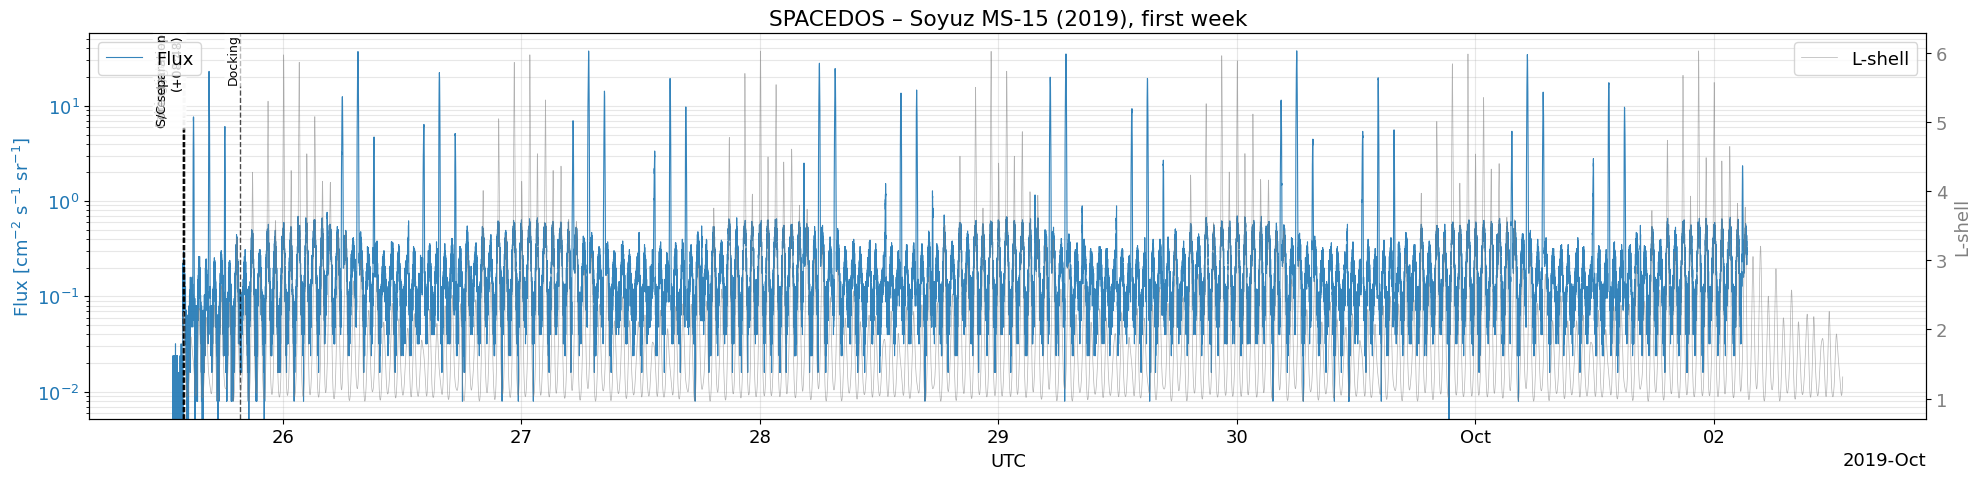

In [92]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

if 'orbit19' in globals() and 'rc19' in globals():
    tmin = events_2019["Launch"] - pd.Timedelta(hours=1)
    tmax = tmin + pd.Timedelta(days=7)

    z  = rc19.loc[(rc19["corr_time"] > tmin) & (rc19["corr_time"] < tmax)]
    zo = orbit19.loc[(orbit19["UTC"] > tmin) & (orbit19["UTC"] < tmax)]

    plt.figure(figsize=(20, 5))
    plt.rcParams.update({'font.size': 13})
    ax = plt.gca()
    ax.plot(z["corr_time"], z["flux"], color='tab:blue', lw=0.8, alpha=0.9, label="Flux")
    ax.set_yscale('log')
    ax.set_xlabel("UTC")
    ax.set_ylabel(r"Flux [cm$^{-2}$ s$^{-1}$ sr$^{-1}$]", color='tab:blue')
    ax.tick_params(axis='y', labelcolor='tab:blue')
    ax.set_title("SPACEDOS – Soyuz MS-15 (2019), first week")
    ax.grid(which='both', alpha=0.3)
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))

    ax2 = ax.twinx()
    ax2.plot(zo["UTC"], zo["L"], color='gray', lw=0.5, alpha=0.6, label="L-shell")
    ax2.set_ylabel("L-shell", color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')

    draw_events(ax, events_2019, tmin, tmax)
    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig("ms15_first_week.png", dpi=300)
    plt.show()
else:
    print("Dependency Missing: Please run the data loading cell for 'orbit19' and 'rc19' first.")

## 6. Plot 2: First Week of 2020 (Soyuz MS-17)

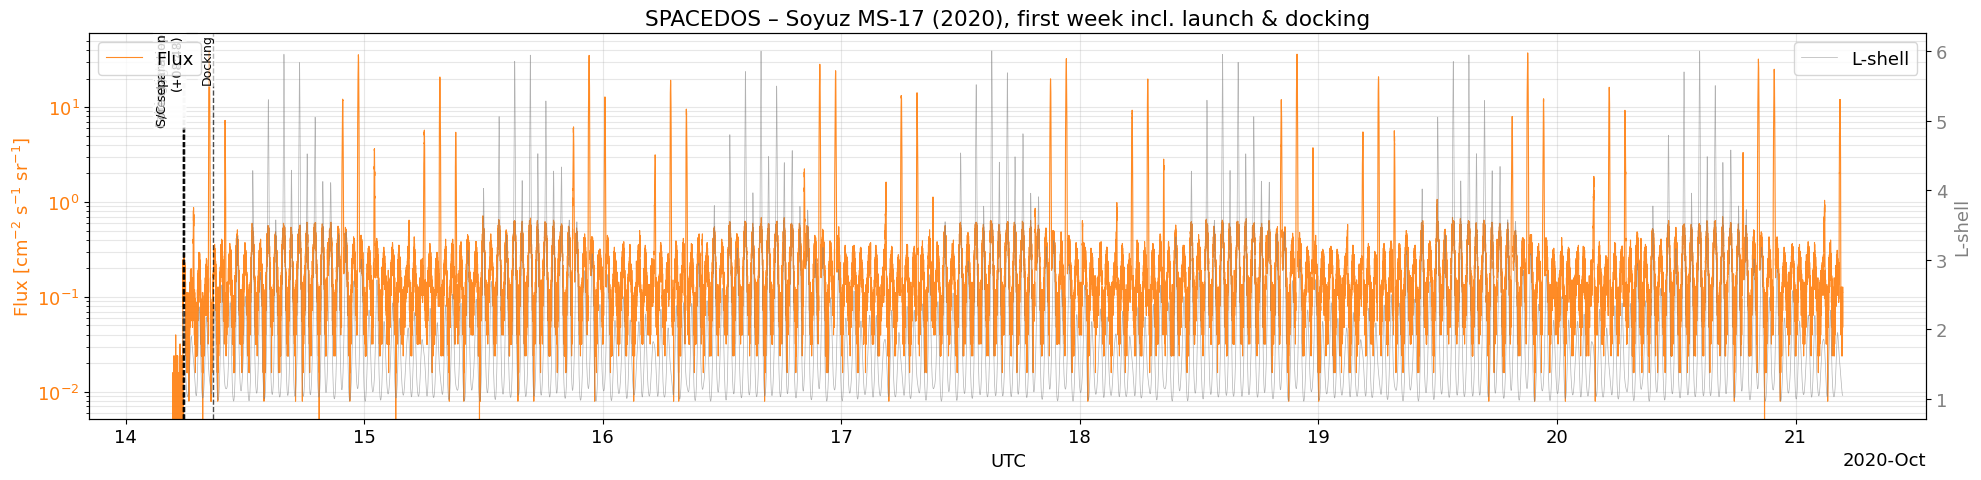

In [93]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

tmin = events_2020["Launch"] - pd.Timedelta(hours=1)
tmax = tmin + pd.Timedelta(days=7)

z  = rc20.loc[(rc20["corr_time"] > tmin) & (rc20["corr_time"] < tmax)]
zo = orbit20.loc[(orbit20["UTC"] > tmin) & (orbit20["UTC"] < tmax)]

plt.figure(figsize=(20, 5))
plt.rcParams.update({'font.size': 13})
ax = plt.gca()
ax.plot(z["corr_time"], z["flux"], color='tab:orange', lw=0.8, alpha=0.9, label="Flux")
ax.set_yscale('log')
ax.set_xlabel("UTC")
ax.set_ylabel(r"Flux [cm$^{-2}$ s$^{-1}$ sr$^{-1}$]", color='tab:orange')
ax.tick_params(axis='y', labelcolor='tab:orange')
ax.set_title("SPACEDOS – Soyuz MS-17 (2020), first week incl. launch & docking")
ax.grid(which='both', alpha=0.3)
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))

ax2 = ax.twinx()
ax2.plot(zo["UTC"], zo["L"], color='gray', lw=0.5, alpha=0.6, label="L-shell")
ax2.set_ylabel("L-shell", color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

draw_events(ax, events_2020, tmin, tmax)
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig("ms17_first_week.png", dpi=300)
plt.show()

## 7. Plot 3: Launch → Docking Comparison

The time axis is relative to the launch time (T+ hours) to allow direct comparison between missions.

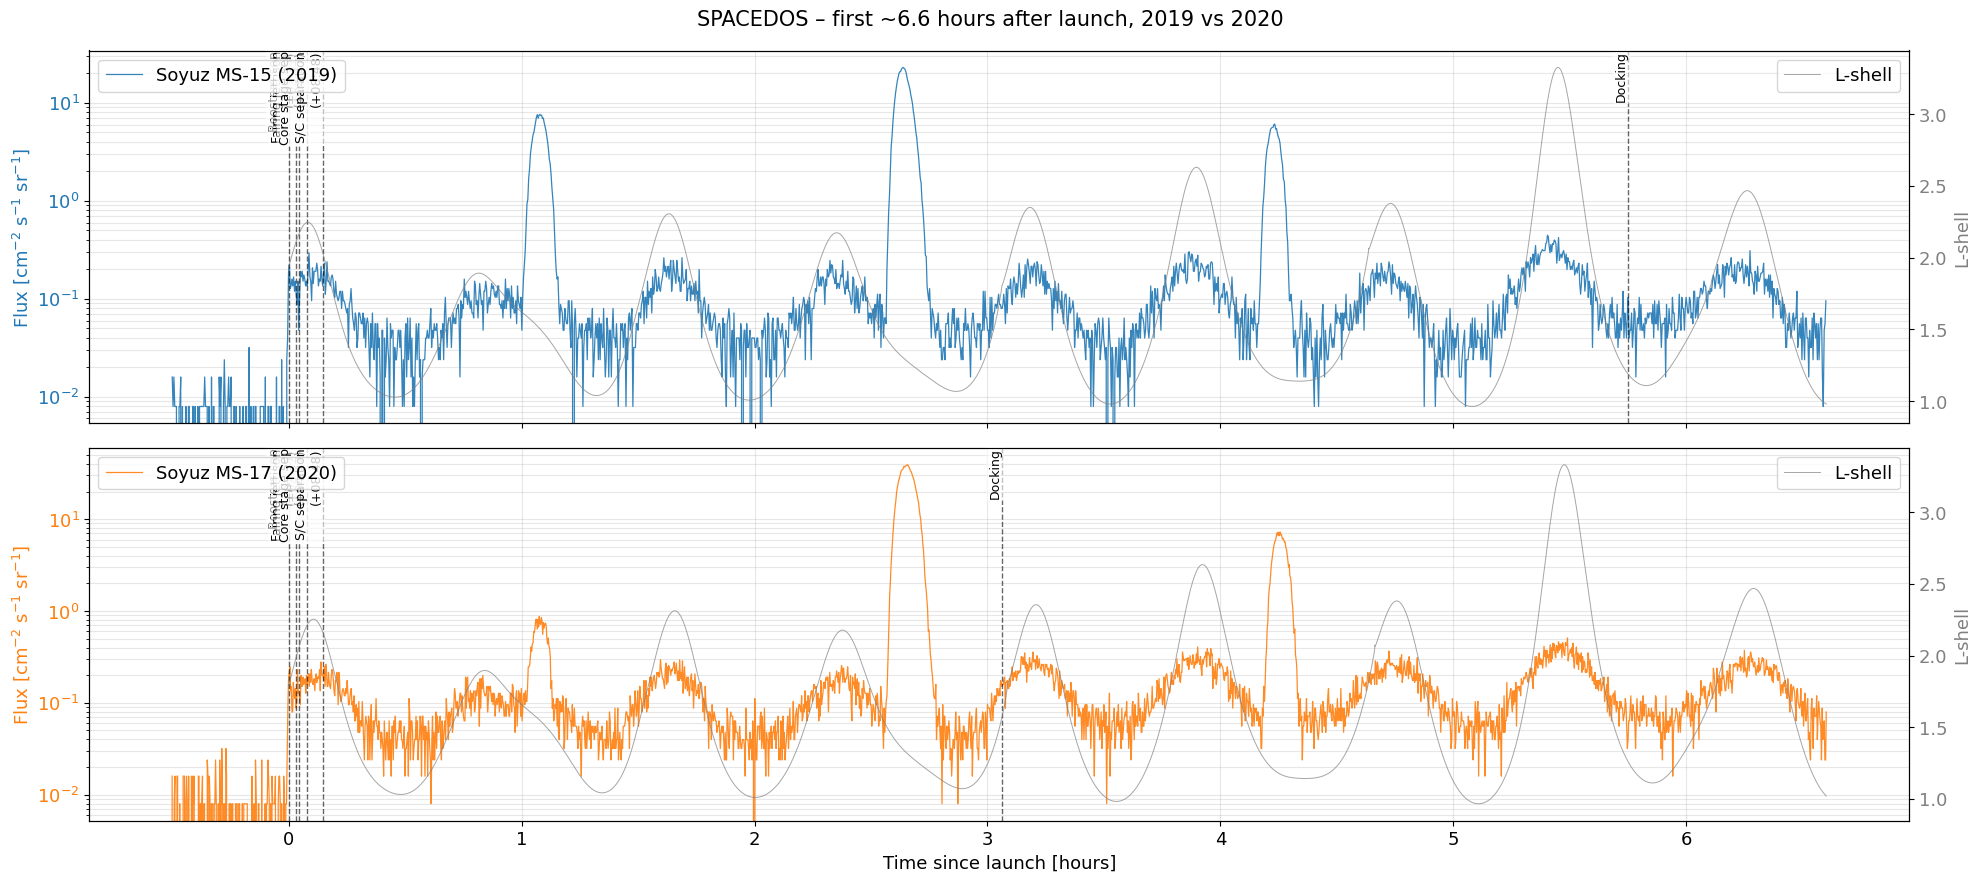

In [94]:
import matplotlib.pyplot as plt
import matplotlib

fig, axes = plt.subplots(2, 1, figsize=(20, 9), sharex=True)
matplotlib.rcParams.update({'font.size': 13})

for ax, rc, orb, events, color, label in [
    (axes[0], rc19, orbit19, events_2019, 'tab:blue',   "Soyuz MS-15 (2019)"),
    (axes[1], rc20, orbit20, events_2020, 'tab:orange', "Soyuz MS-17 (2020)"),
]:
    launch = events["Launch"]
    tmin = launch - pd.Timedelta(minutes=30)
    tmax = launch + pd.Timedelta(hours=6.6)

    z  = rc.loc[(rc["corr_time"] > tmin) & (rc["corr_time"] < tmax)].copy()
    zo = orb.loc[(orb["UTC"] > tmin) & (orb["UTC"] < tmax)].copy()
    z["t_hours"]  = (z["corr_time"] - launch).dt.total_seconds() / 3600.0
    zo["t_hours"] = (zo["UTC"] - launch).dt.total_seconds() / 3600.0

    ax.plot(z["t_hours"], z["flux"], color=color, lw=0.9, alpha=0.9, label=label)
    ax.set_yscale('log')
    ax.set_ylabel(r"Flux [cm$^{-2}$ s$^{-1}$ sr$^{-1}$]", color=color)
    ax.tick_params(axis='y', labelcolor=color)
    ax.grid(which='both', alpha=0.3)
    ax.legend(loc='upper left')

    ax2 = ax.twinx()
    ax2.plot(zo["t_hours"], zo["L"], color='gray', lw=0.7, alpha=0.7, label="L-shell")
    ax2.set_ylabel("L-shell", color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')
    ax2.legend(loc='upper right')

    ymin, ymax = ax.get_ylim()
    for name, t in events.items():
        t_rel = (t - launch).total_seconds() / 3600.0
        if -0.5 <= t_rel <= 6.6:
            ax.axvline(t_rel, linestyle="--", linewidth=1, color='black', alpha=0.6)
            ax.text(t_rel, ymax, name,
                    rotation=90, va="top", ha="right", fontsize=9,
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6))

axes[1].set_xlabel("Time since launch [hours]")
fig.suptitle("SPACEDOS – first ~6.6 hours after launch, 2019 vs 2020", fontsize=15)
plt.tight_layout()
plt.savefig("launch_comparison_6h.png", dpi=300)
plt.show()

## 8. Detail: First hour after launch – SAA passage

Logarithmic scale for flux clearly shows the increase during the radiation belt passage in the first hour.

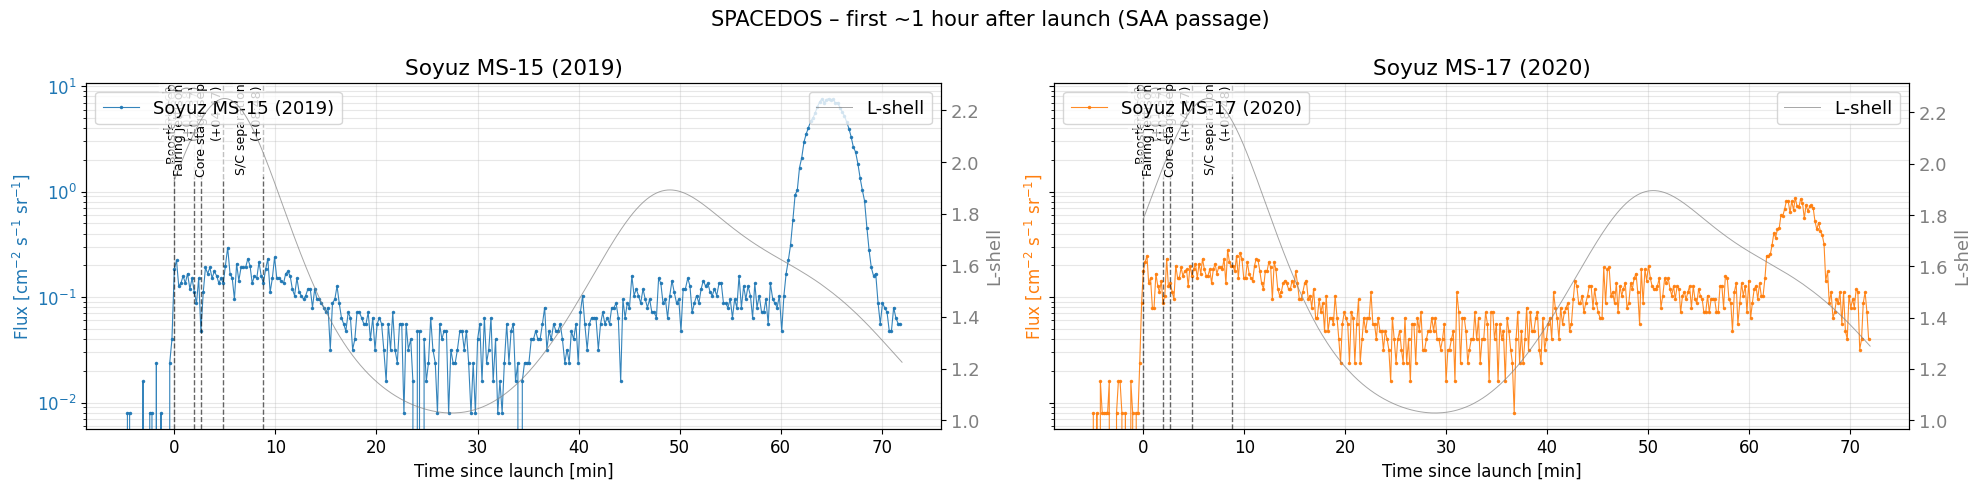

In [124]:
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(20, 5), sharey=True)
matplotlib.rcParams.update({'font.size': 13})

for ax, rc, orb, events, color, label in [
    (axes[0], rc19, orbit19, events_2019, 'tab:blue',   "Soyuz MS-15 (2019)"),
    (axes[1], rc20, orbit20, events_2020, 'tab:orange', "Soyuz MS-17 (2020)"),
]:
    launch = events["Launch"]
    # Detail window: 5 minutes before to 1.2 hours (72 min) after launch
    tmin = launch - pd.Timedelta(minutes=5)
    tmax = launch + pd.Timedelta(hours=1.2)

    z  = rc.loc[(rc["corr_time"] > tmin) & (rc["corr_time"] < tmax)].copy()
    zo = orb.loc[(orb["UTC"] > tmin) & (orb["UTC"] < tmax)].copy()
    z["t_min"]  = (z["corr_time"] - launch).dt.total_seconds() / 60.0
    zo["t_min"] = (zo["UTC"] - launch).dt.total_seconds() / 60.0

    ax.plot(z["t_min"], z["flux"], marker='.', ms=3, lw=0.8, color=color, alpha=0.9, label=label)
    ax.set_yscale('log')
    ax.set_xlabel("Time since launch [min]")
    ax.set_ylabel(r"Flux [cm$^{-2}$ s$^{-1}$ sr$^{-1}$]", color=color)
    ax.tick_params(axis='y', labelcolor=color)
    ax.grid(which='both', alpha=0.3)
    ax.legend(loc='upper left')
    ax.set_title(label)

    ax2 = ax.twinx()
    ax2.plot(zo["t_min"], zo["L"], color='gray', lw=0.7, alpha=0.7, label="L-shell")
    ax2.set_ylabel("L-shell", color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')
    ax2.legend(loc='upper right')

    # MODIFIED: Draw only events within the range of this specific detail plot
    ymin, ymax = ax.get_ylim()
    for name, t in events.items():
        t_rel_min = (t - launch).total_seconds() / 60.0
        if -5 <= t_rel_min <= 72:
            ax.axvline(t_rel_min, linestyle="--", linewidth=1, color='black', alpha=0.6)
            ax.text(t_rel_min, ymax, name, rotation=90, va="top", ha="right", fontsize=9,
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6))

fig.suptitle("SPACEDOS – first ~1 hour after launch (SAA passage)", fontsize=15)
plt.tight_layout()
plt.savefig("saa_passage_detail.png", dpi=300)
plt.show()

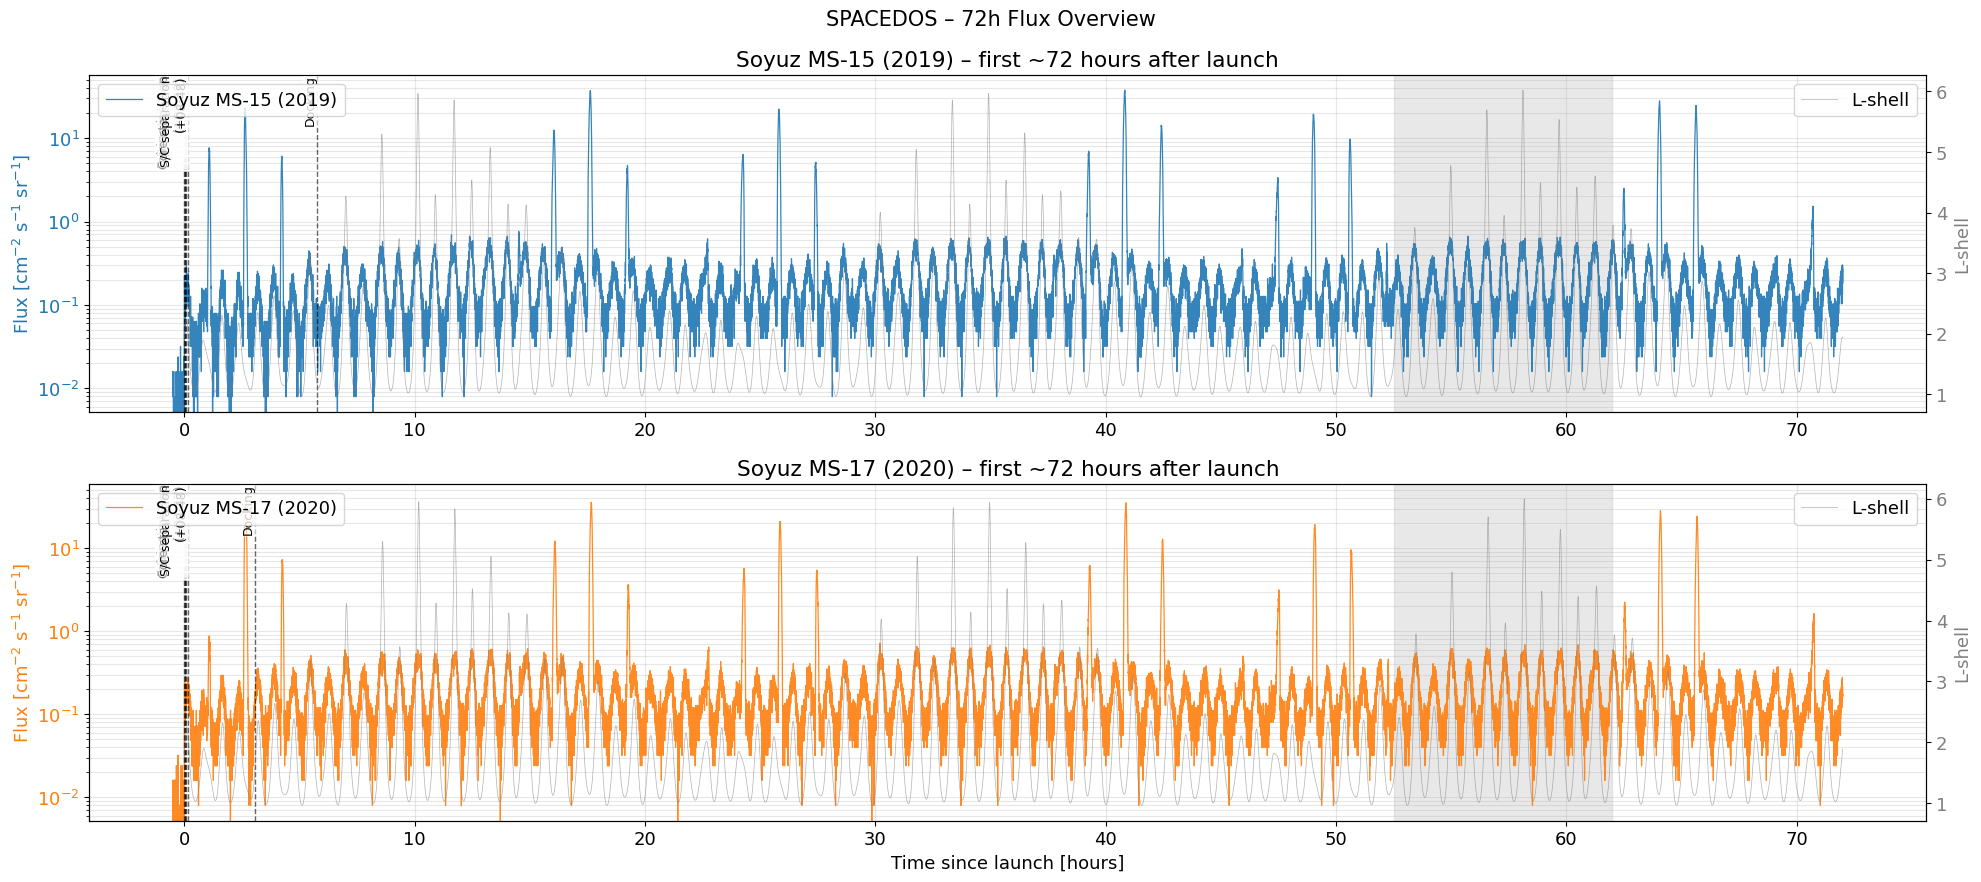

In [125]:
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd

fig, axes = plt.subplots(2, 1, figsize=(20, 9), sharex=False)
matplotlib.rcParams.update({'font.size': 13})

for i, (ax, rc, orb, events, color, label) in enumerate([
    (axes[0], rc19, orbit19, events_2019, 'tab:blue',   "Soyuz MS-15 (2019)"),
    (axes[1], rc20, orbit20, events_2020, 'tab:orange', "Soyuz MS-17 (2020)"),
]):
    launch = events["Launch"]
    tmin = launch - pd.Timedelta(minutes=30)
    tmax = launch + pd.Timedelta(hours=72)

    z  = rc.loc[(rc["corr_time"] > tmin) & (rc["corr_time"] < tmax)].copy()
    zo = orb.loc[(orb["UTC"] > tmin) & (orb["UTC"] < tmax)].copy()
    z["t_hours"]  = (z["corr_time"] - launch).dt.total_seconds() / 3600.0
    zo["t_hours"] = (zo["UTC"] - launch).dt.total_seconds() / 3600.0

    ax.plot(z["t_hours"], z["flux"], color=color, lw=0.9, alpha=0.9, label=label)
    ax.set_yscale('log')
    ax.set_ylabel(r"Flux [cm$^{-2}$ s$^{-1}$ sr$^{-1}$]", color=color)
    ax.tick_params(axis='y', labelcolor=color)
    ax.grid(which='both', alpha=0.3)
    ax.legend(loc='upper left')
    ax.set_title(label + " – first ~72 hours after launch")
    ax.axvspan(52.5, 62, color='lightgray', alpha=0.5, label='highlighted range')

    ax2 = ax.twinx()
    ax2.plot(zo["t_hours"], zo["L"], color='gray', lw=0.5, alpha=0.6, label="L-shell")
    ax2.set_ylabel("L-shell", color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')
    ax2.legend(loc='upper right')

    # MODIFIED: Draw only events within the range of this specific plot (-0.5h to 72h)
    ymin, ymax = ax.get_ylim()
    for name, t in events.items():
        t_rel = (t - launch).total_seconds() / 3600.0
        if -0.5 <= t_rel <= 72:
            ax.axvline(t_rel, linestyle="--", linewidth=1, color='black', alpha=0.6)
            ax.text(t_rel, ymax, name, rotation=90, va="top", ha="right", fontsize=9,
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6))

axes[1].set_xlabel("Time since launch [hours]")
fig.suptitle("SPACEDOS – 72h Flux Overview", fontsize=15)
plt.tight_layout()
plt.savefig("72h_overview_highlighted.png", dpi=300)
plt.show()

## Detail of the highlighted range (~52.5 to 62 hours after launch)

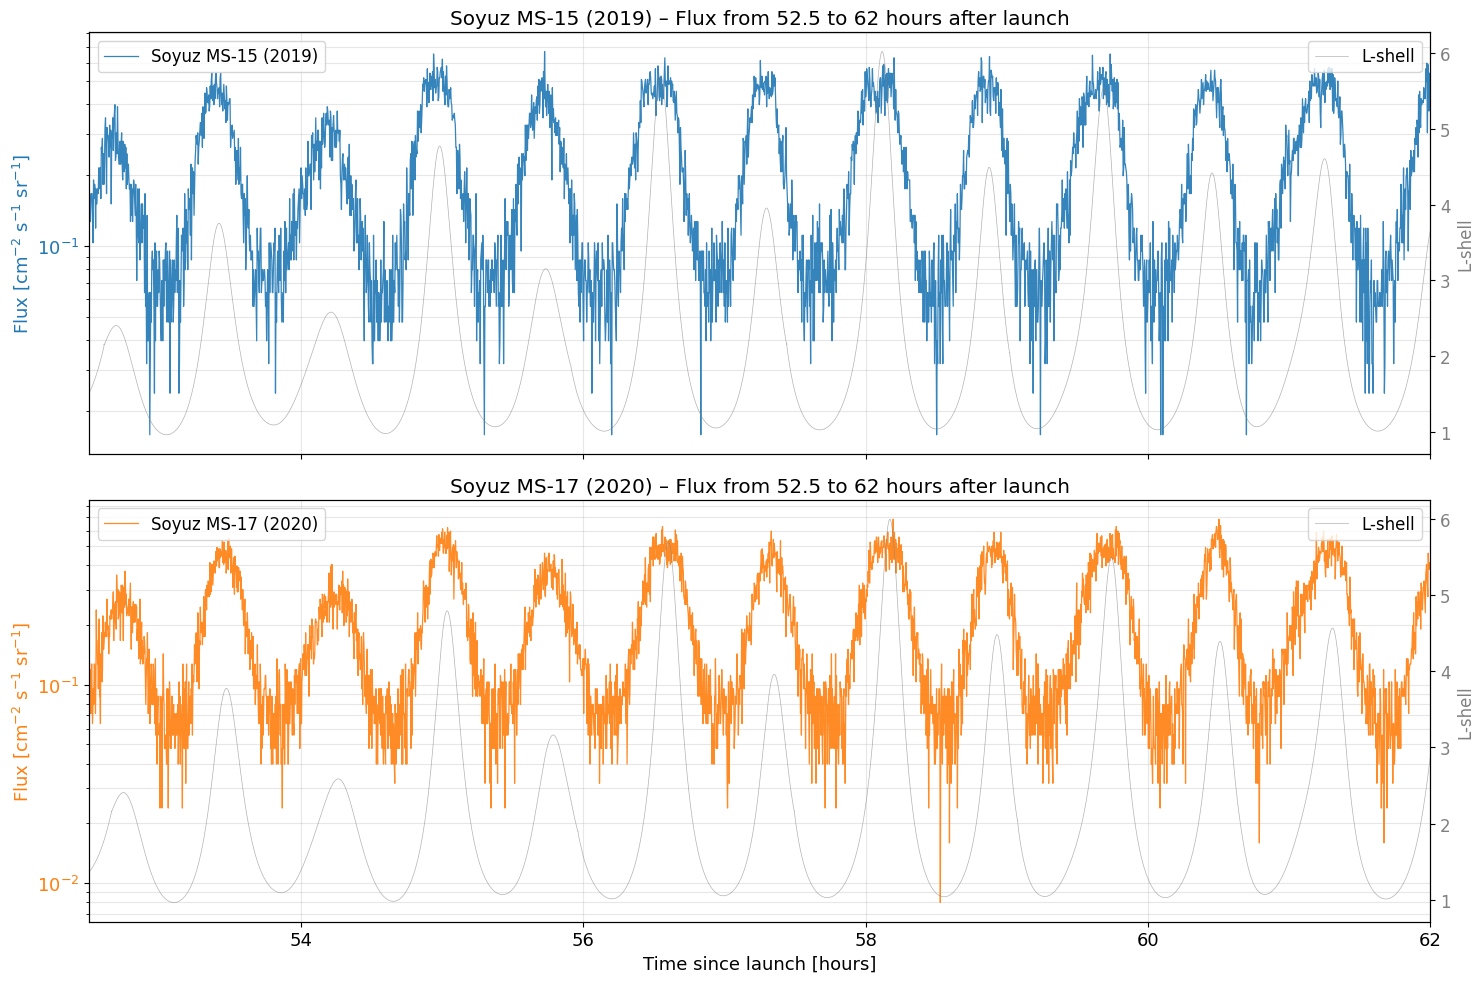

In [97]:
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
matplotlib.rcParams.update({'font.size': 12})

# Define the highlighted time range in hours relative to launch
highlight_start_hours = 52.5
highlight_end_hours = 62

if 'orbit19' in globals():
    for i, (ax, rc, orb, events, color, label) in enumerate([
        (axes[0], rc19, orbit19, events_2019, 'tab:blue',   "Soyuz MS-15 (2019)"),
        (axes[1], rc20, orbit20, events_2020, 'tab:orange', "Soyuz MS-17 (2020)"),
    ]):
        launch = events["Launch"]
        tmin_highlight = launch + pd.Timedelta(hours=highlight_start_hours)
        tmax_highlight = launch + pd.Timedelta(hours=highlight_end_hours)

        z  = rc.loc[(rc["corr_time"].notna()) & (rc["corr_time"] >= tmin_highlight) & (rc["corr_time"] <= tmax_highlight)].copy()
        zo = orb.loc[(orb["UTC"] >= tmin_highlight) & (orb["UTC"] <= tmax_highlight)].copy()

        z["t_hours" ]  = (z["corr_time"] - launch).dt.total_seconds() / 3600.0
        zo["t_hours"] = (zo["UTC"] - launch).dt.total_seconds() / 3600.0

        ax.plot(z["t_hours"], z["flux"], color=color, lw=0.9, alpha=0.9, label=label)
        ax.set_yscale('log')
        ax.set_ylabel(r"Flux [cm$^{-2}$ s$^{-1}$ sr$^{-1}$]", color=color)
        ax.tick_params(axis='y', labelcolor=color)
        ax.grid(which='both', alpha=0.3)
        ax.legend(loc='upper left')
        ax.set_title(f"{label} \u2013 Flux from {highlight_start_hours} to {highlight_end_hours} hours after launch")
        ax.set_xlim(highlight_start_hours, highlight_end_hours)

        ax2 = ax.twinx()
        ax2.plot(zo["t_hours"], zo["L"], color='gray', lw=0.5, alpha=0.6, label="L-shell")
        ax2.set_ylabel("L-shell", color='gray')
        ax2.tick_params(axis='y', labelcolor='gray')
        ax2.legend(loc='upper right')

    axes[1].set_xlabel("Time since launch [hours]")
    plt.tight_layout()
    plt.show()
else:
    print("Dependencies missing. Please run orbit and data loading cells.")

## 9. Flux and L-shell Correlation with Time Shift

Below we calculate the Pearson correlation between `flux` and `L-shell` for the previously highlighted range (52.5 to 62 hours after launch). We investigate how the correlation changes when shifting the `L-shell` data relative to `flux` by ± 3 minutes in 10-second steps.

In [98]:
def calculate_shifted_correlation(flux_df, l_shell_df, time_shift_seconds):
    """
    Calculates the Pearson correlation between flux and L-shell with a given time shift.

    Args:
        flux_df (pd.DataFrame): DataFrame with 'corr_time' (datetime) and 'flux'.
        l_shell_df (pd.DataFrame): DataFrame with 'UTC' (datetime) and 'L'.
        time_shift_seconds (int): Time shift in seconds to apply to FLUX data.

    Returns:
        float: Pearson correlation coefficient.
    """
    # Create a copy of flux_df to apply shift, avoid modifying original
    shifted_flux_df = flux_df.copy()
    shifted_flux_df['corr_time_shifted'] = shifted_flux_df['corr_time'] + pd.Timedelta(seconds=time_shift_seconds)

    # Sort both dataframes by their time columns for merge_asof
    shifted_flux_df_sorted = shifted_flux_df.sort_values(by='corr_time_shifted')
    l_shell_df_sorted = l_shell_df.sort_values(by='UTC') # L-shell is NOT shifted

    # Merge shifted flux and unshifted L-shell data. 'left_on' is shifted_flux_df's time, 'right_on' is L-shell's time.
    # 'direction='nearest' finds the closest match within tolerance.
    merged_df = pd.merge_asof(
        shifted_flux_df_sorted,
        l_shell_df_sorted[['UTC', 'L']], # Use unshifted UTC for L-shell
        left_on='corr_time_shifted',
        right_on='UTC',
        direction='nearest',
        tolerance=pd.Timedelta(seconds=5) # Allow 5 seconds difference for matching flux (10s integration)
    )

    # Drop rows where 'flux' or 'L' might be NaN if no match was found within tolerance or original NaNs
    merged_df = merged_df.dropna(subset=['flux', 'L'])

    if len(merged_df) > 1: # Need at least 2 points to calculate correlation
        return merged_df['flux'].corr(merged_df['L'])
    else:
        return np.nan # Not enough data for correlation

In [99]:
# Define the highlighted time range in hours relative to launch
highlight_start_hours = 52.5
highlight_end_hours = 62

# --- Prepare data for 2019 ---
launch_2019 = events_2019['Launch']
tmin_2019_highlight = launch_2019 + pd.Timedelta(hours=highlight_start_hours)
tmax_2019_highlight = launch_2019 + pd.Timedelta(hours=highlight_end_hours)

z19_highlight = rc19.loc[(rc19['corr_time'] >= tmin_2019_highlight) & (rc19['corr_time'] <= tmax_2019_highlight)].copy()
zo19_highlight = orbit19.loc[(orbit19['UTC'] >= tmin_2019_highlight) & (orbit19['UTC'] <= tmax_2019_highlight)].copy()

# --- Prepare data for 2020 ---
launch_2020 = events_2020['Launch']
tmin_2020_highlight = launch_2020 + pd.Timedelta(hours=highlight_start_hours)
tmax_2020_highlight = launch_2020 + pd.Timedelta(hours=highlight_end_hours)

z20_highlight = rc20.loc[(rc20['corr_time'] >= tmin_2020_highlight) & (rc20['corr_time'] <= tmax_2020_highlight)].copy()
zo20_highlight = orbit20.loc[(orbit20['UTC'] >= tmin_2020_highlight) & (orbit20['UTC'] <= tmax_2020_highlight)].copy()

# Generate a range of time shifts (from -180s to +180s, step 10s)
shifts = np.arange(-180, 181, 10)

correlations_2019 = []
correlations_2020 = []

print(f'Calculating correlations for 2019 ({len(z19_highlight)} flux points)... ')
for shift in shifts:
    corr_19 = calculate_shifted_correlation(z19_highlight, zo19_highlight, shift)
    correlations_2019.append(corr_19)

print(f'Calculating correlations for 2020 ({len(z20_highlight)} flux points)... ')
for shift in shifts:
    corr_20 = calculate_shifted_correlation(z20_highlight, zo20_highlight, shift)
    correlations_2020.append(corr_20)

print('Correlation calculation complete. Now you can run the precise peak fitting cell.')

Calculating correlations for 2019 (2576 flux points)... 
Calculating correlations for 2020 (3217 flux points)... 
Correlation calculation complete. Now you can run the precise peak fitting cell.


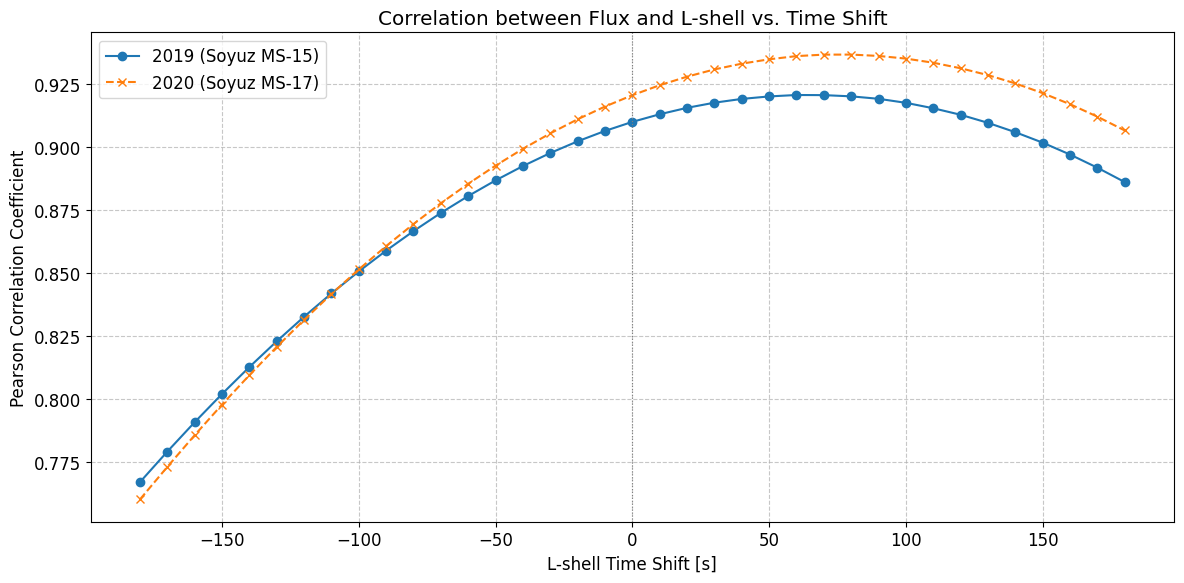

In [100]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

if 'shifts' in globals() and 'correlations_2019' in globals():
    plt.figure(figsize=(12, 6))
    matplotlib.rcParams.update({'font.size': 12})

    plt.plot(shifts, correlations_2019, marker='o', linestyle='-', label='2019 (Soyuz MS-15)', color='tab:blue')
    plt.plot(shifts, correlations_2020, marker='x', linestyle='--', label='2020 (Soyuz MS-17)', color='tab:orange')

    plt.title('Correlation between Flux and L-shell vs. Time Shift')
    plt.xlabel('L-shell Time Shift [s]')
    plt.ylabel('Pearson Correlation Coefficient')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.axvline(0, color='grey', linestyle=':', linewidth=0.8)
    plt.tight_layout()
    plt.savefig("correlation_vs_shift.png", dpi=300)
    plt.show()
else:
    print("Dependency Missing: 'shifts' or 'correlations' not found. Please run the correlation calculation cell first.")

## 10. Optimal Time Shifts for Maximum Correlation

Let's find the specific time shifts that result in the highest Pearson correlation coefficient for each year within the analyzed range.

In [101]:
# Find the index of the maximum correlation for 2019
max_corr_19_index = np.nanargmax(correlations_2019)
optimal_shift_19 = shifts[max_corr_19_index]
max_correlation_19 = correlations_2019[max_corr_19_index]

# Find the index of the maximum correlation for 2020
max_corr_20_index = np.nanargmax(correlations_2020)
optimal_shift_20 = shifts[max_corr_20_index]
max_correlation_20 = correlations_2020[max_corr_20_index]

print(f"For 2019 (Soyuz MS-15), the maximum correlation ({max_correlation_19:.4f}) occurs at a time shift of {optimal_shift_19} seconds.")
print(f"For 2020 (Soyuz MS-17), the maximum correlation ({max_correlation_20:.4f}) occurs at a time shift of {optimal_shift_20} seconds.")

For 2019 (Soyuz MS-15), the maximum correlation (0.9207) occurs at a time shift of 60 seconds.
For 2020 (Soyuz MS-17), the maximum correlation (0.9367) occurs at a time shift of 80 seconds.


## 11. Precise Optimal Time Shifts via Curve Fitting

To determine the optimal time shifts with higher precision than the 10-second step size, we can fit a parabolic curve to the correlation values around their respective peaks. The vertex of this parabola will give us a more accurate estimate of the true maximum correlation and the corresponding time shift.

In [102]:
from scipy.optimize import curve_fit
import numpy as np

def parabolic_fit(x, a, b, c):
    return a * x**2 + b * x + c

def calculate_shift_error(popt, pcov):
    a, b, _ = popt
    if np.isclose(a, 0): return np.nan
    df_da = b / (2 * a**2)
    df_db = -1 / (2 * a)
    var_a, var_b, cov_ab = pcov[0, 0], pcov[1, 1], pcov[0, 1]
    var_shift = (df_da**2 * var_a) + (df_db**2 * var_b) + (2 * df_da * df_db * cov_ab)
    return np.sqrt(var_shift) if var_shift >= 0 else np.nan

def find_precise_peak(shifts, correlations):
    shifts_arr, correlations_arr = np.array(shifts), np.array(correlations)
    max_corr_idx = np.nanargmax(correlations_arr)
    window_size = 2
    start_idx = max(0, max_corr_idx - window_size)
    end_idx = min(len(shifts_arr) - 1, max_corr_idx + window_size)
    x_data, y_data = shifts_arr[start_idx : end_idx + 1], correlations_arr[start_idx : end_idx + 1]

    try:
        popt, pcov = curve_fit(parabolic_fit, x_data, y_data, p0=[-0.0001, 0, correlations_arr[max_corr_idx]])
        precise_shift = -popt[1] / (2 * popt[0])
        return precise_shift, parabolic_fit(precise_shift, *popt), calculate_shift_error(popt, pcov)
    except:
        return float(shifts_arr[max_corr_idx]), float(correlations_arr[max_corr_idx]), np.nan

# Calculate precise peaks
if 'shifts' in globals() and 'correlations_2019' in globals():
    precise_shift_19, precise_correlation_19, error_19 = find_precise_peak(shifts, correlations_2019)
    precise_shift_20, precise_correlation_20, error_20 = find_precise_peak(shifts, correlations_2020)
    print(f"Precise optimal shift for 2019 (Soyuz MS-15): {precise_shift_19:.2f}s")
    print(f"Precise optimal shift for 2020 (Soyuz MS-17): {precise_shift_20:.2f}s")
else:
    print("Error: Correlation data missing. Please run cell 4f4d975b (shift calculation) first.")

Precise optimal shift for 2019 (Soyuz MS-15): 65.02s
Precise optimal shift for 2020 (Soyuz MS-17): 75.46s


## 12. Flux and L-shell (shifted) visualization around launch (-15 min to +1 hour)

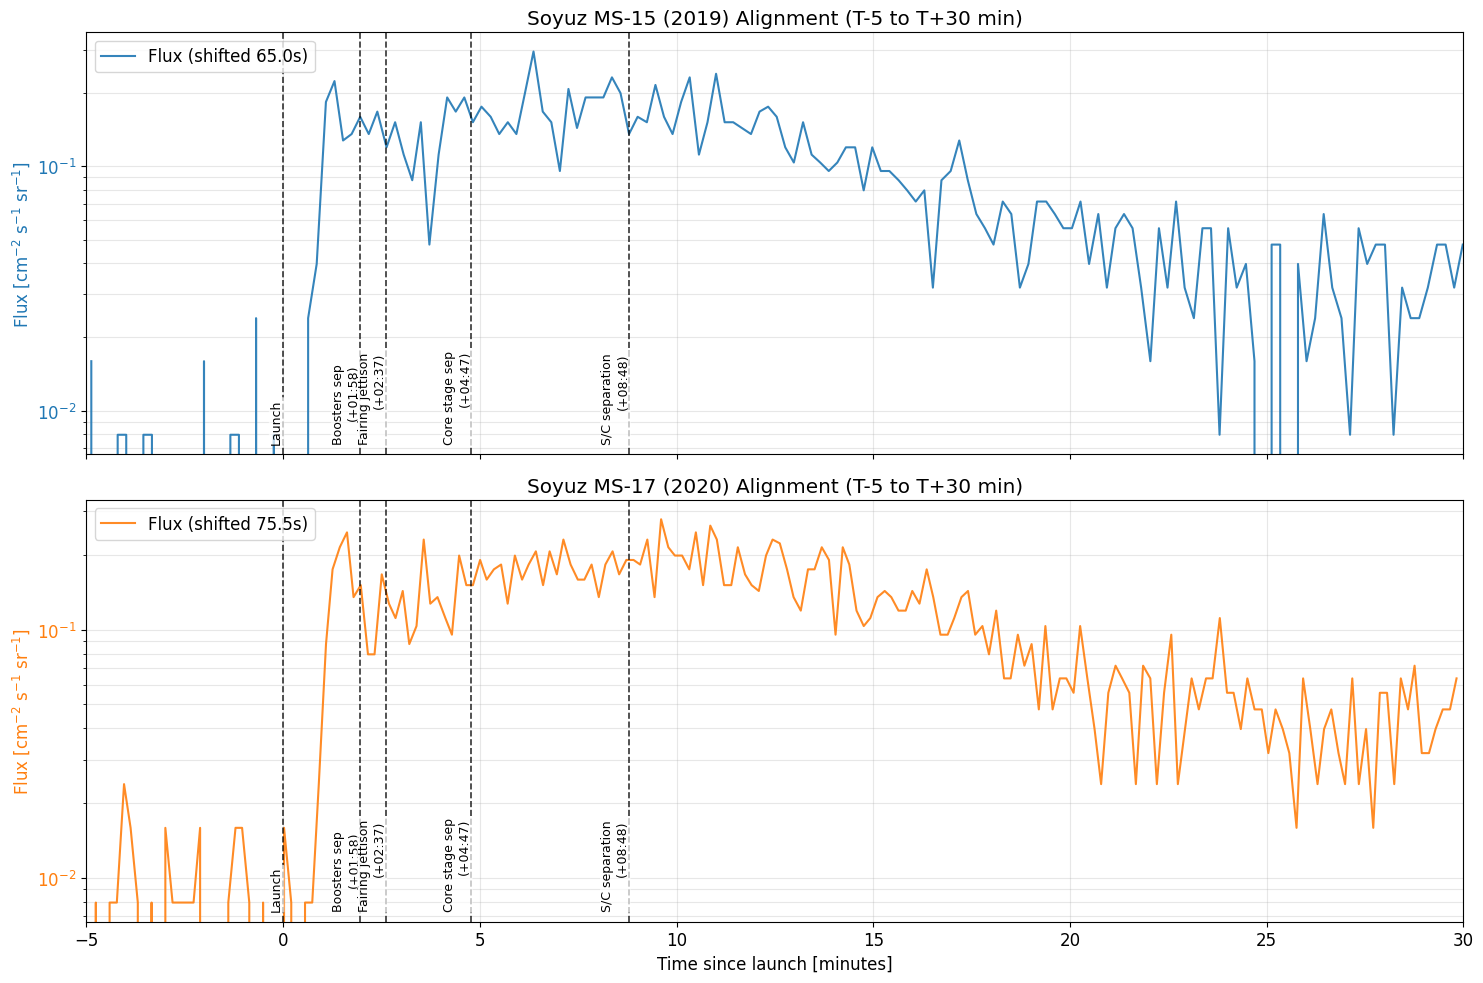


--- Flight Phase Dose Comparison Summary ---


,Mission,Duration [h],Total Dose [µGy]
0,Soyuz MS-15 (2019),5.75,188.16
1,Soyuz MS-17 (2020),3.06,249.28


In [123]:
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import numpy as np

if 'precise_shift_19' in globals():
    fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
    matplotlib.rcParams.update({'font.size': 12})

    plot_data = [
        (rc19, events_2019, 'tab:blue',   "Soyuz MS-15 (2019)", precise_shift_19),
        (rc20, events_2020, 'tab:orange', "Soyuz MS-17 (2020)", precise_shift_20),
    ]

    for i, (rc, events, color, label, time_shift) in enumerate(plot_data):
        ax = axes[i]
        launch = events["Launch"]
        # Detail window: 5 minutes before to 30 minutes after launch
        tmin_display = launch - pd.Timedelta(minutes=5)
        tmax_display = launch + pd.Timedelta(minutes=30)

        # 1. Filter and shift radiation flux
        z = rc.loc[(rc["corr_time"] >= tmin_display - pd.Timedelta(seconds=time_shift)) &
                   (rc["corr_time"] <= tmax_display - pd.Timedelta(seconds=time_shift))].copy()
        z["t_min_shifted"] = (z["corr_time"] + pd.Timedelta(seconds=time_shift) - launch).dt.total_seconds() / 60.0

        # Plot Flux
        ax.plot(z["t_min_shifted"], z["flux"], color=color, lw=1.5, alpha=0.9, label=f'Flux (shifted {time_shift:.1f}s)')
        ax.set_yscale('log')
        ax.set_ylabel(r"Flux [cm$^{-2}$ s$^{-1}$ sr$^{-1}$]", color=color)
        ax.tick_params(axis='y', labelcolor=color)
        ax.grid(which='both', alpha=0.3)
        ax.set_title(f"{label} Alignment (T-5 to T+30 min)")
        ax.set_xlim(-5, 30)

        # --- MODIFIED: Draw vertical event lines (black, dashed, labels at bottom) ---
        ymin, ymax = ax.get_ylim()
        for name, t in events.items():
            t_rel_min = (t - launch).total_seconds() / 60.0
            if -5 <= t_rel_min <= 30:
                ax.axvline(t_rel_min, linestyle="--", linewidth=1.2, color='black', alpha=0.8)
                # Placing text at the bottom (ymin)
                ax.text(t_rel_min, ymin * 1.1, name, rotation=90, va="bottom", ha="right",
                        fontsize=9, color='black', bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.7))

        ax.legend(loc='upper left')

    axes[1].set_xlabel("Time since launch [minutes]")
    plt.tight_layout()
    plt.savefig("alignment_launch_simplified.png", dpi=300)
    plt.show()

    if 'df_dose' in globals():
        print("\n--- Flight Phase Dose Comparison Summary ---")
        display(df_dose)
else:
    print("Run peak fitting cell 02dfc3fa first.")

### Altitude Anchor Table for Soyuz Ascent (MSL — above mean sea level)

| Event | T+ [s] | Altitude MSL [km] | Source |
|---|---|---|---|
| Launch (Baikonur Site 1/31) | 0 | 0.09 | Baikonur 90 m n.m. |
| End of vertical climb | ~10 | ~0.2 | R-7 Operational Procedure |
| Boosters separation (Korolev cross) | 118 | ~45 | Krikalev (MS-10): Everyday Astronaut |
| Fairing jettison | ~157 | ~100 | ESA Cluster |
| Core stage separation | ~287 | ~170–176 | ESA / NASA |
| S/C separation (3rd stage cutoff) | ~528 | ~210–220 | ESA |

## Altitude over Time from Table

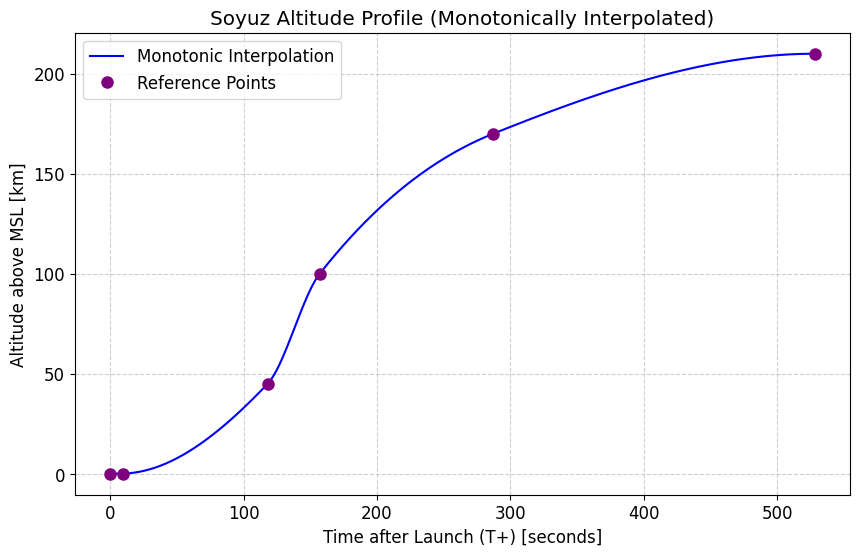

In [104]:
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

# English anchor table content for interpolation
table_content = """
| Event | T+ [s] | Altitude MSL [km] | Source |
|---|---|---|---|
| Launch (Baikonur Site 1/31) | 0 | 0.09 | Baikonur 90 m n.m. |
| End of vertical climb | 10 | 0.20 | R-7 Procedure |
| Boosters sep (Korolev cross) | 118 | 45.00 | Krikalev (MS-10) |
| Fairing jettison | 157 | 100.00 | ESA Cluster |
| Core stage separation | 287 | 170.00 | ESA / NASA |
| S/C separation (3rd stage cutoff) | 528 | 210.00 | ESA |
"""

df_table = pd.read_csv(io.StringIO(table_content), sep='|', header=0, skipinitialspace=True)
df_table = df_table.iloc[1:].dropna(axis=1, how='all')
df_table.columns = ['Event', 'T_plus_s', 'Altitude_km', 'Source']

df_table['T_plus_s'] = pd.to_numeric(df_table['T_plus_s'], errors='coerce')
df_table['Altitude_km'] = pd.to_numeric(df_table['Altitude_km'], errors='coerce')
df_table = df_table.dropna(subset=['T_plus_s']).reset_index(drop=True)

t_interp = np.linspace(df_table['T_plus_s'].min(), df_table['T_plus_s'].max(), 500)
f_interp = PchipInterpolator(df_table['T_plus_s'], df_table['Altitude_km'])
altitude_interp = f_interp(t_interp)

plt.figure(figsize=(10, 6))
plt.plot(t_interp, altitude_interp, linestyle='-', color='blue', label='Monotonic Interpolation')
plt.plot(df_table['T_plus_s'], df_table['Altitude_km'], marker='o', linestyle='None', color='purple', markersize=8, label='Reference Points')
plt.title('Soyuz Altitude Profile (Monotonically Interpolated)')
plt.xlabel('Time after Launch (T+) [seconds]')
plt.ylabel('Altitude above MSL [km]')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

### Analytical Altitude Profile Approximation

While the `PchipInterpolator` is accurate for visualization, it is often useful for calculations to have a polynomial function in the form of $h(t) = a_n t^n + ... + a_0$.

Polynomial coefficients for 0-100 km range calculated.


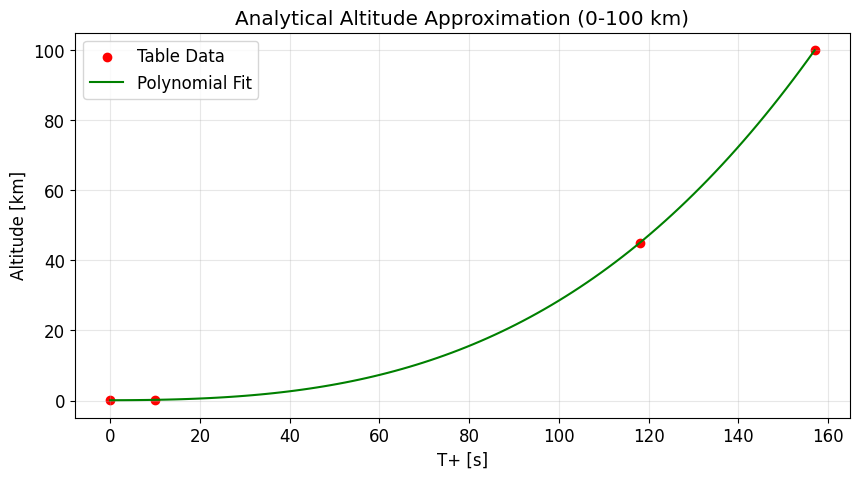

In [105]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure we have the anchor table data from cell 32234898
if 'df_table' in globals():
    mask_100km = df_table['Altitude_km'] <= 100
    x_limited = df_table.loc[mask_100km, 'T_plus_s'].values
    y_limited = df_table.loc[mask_100km, 'Altitude_km'].values

    # Polynomial fit (3rd degree) for the ascent phase 0-100km
    coeffs = np.polyfit(x_limited, y_limited, 3)
    poly_func = np.poly1d(coeffs)

    print("Polynomial coefficients for 0-100 km range calculated.")

    # Visualization
    t_fine = np.linspace(0, x_limited.max(), 100)
    plt.figure(figsize=(10, 5))
    plt.scatter(x_limited, y_limited, color='red', label='Table Data')
    plt.plot(t_fine, poly_func(t_fine), label='Polynomial Fit', color='green')
    plt.title("Analytical Altitude Approximation (0-100 km)")
    plt.xlabel("T+ [s]")
    plt.ylabel("Altitude [km]")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Error: Run cell 32234898 first to load the anchor table.")

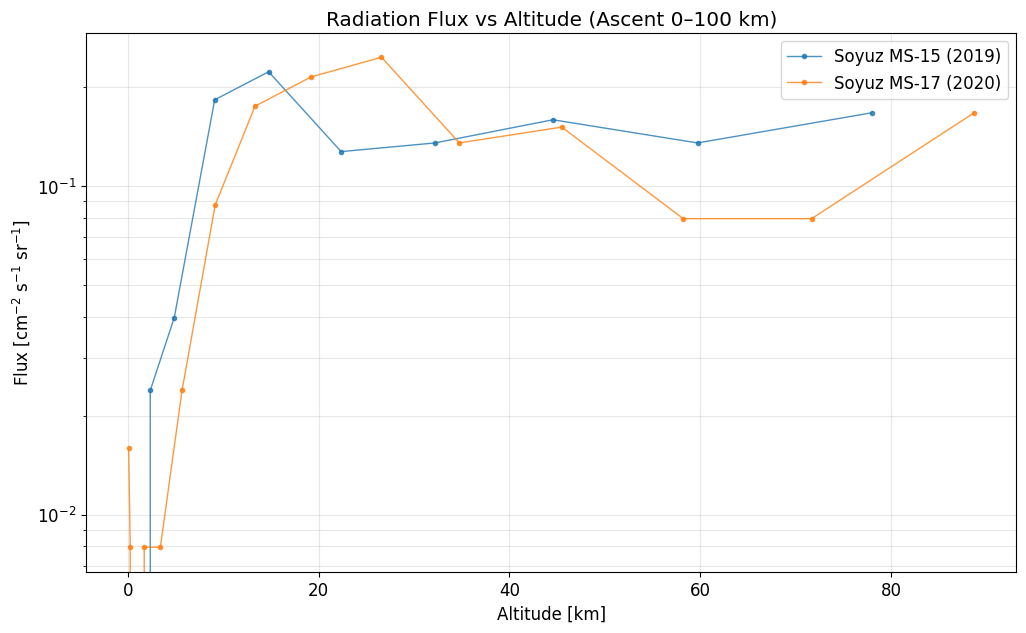

In [106]:
import matplotlib.pyplot as plt
import pandas as pd

if 'precise_shift_19' in globals() and 'poly_func' in globals():
    plt.figure(figsize=(12, 7))
    plot_data_ascent = [
        (rc19, events_2019, 'tab:blue', "Soyuz MS-15 (2019)", precise_shift_19),
        (rc20, events_2020, 'tab:orange', "Soyuz MS-17 (2020)", precise_shift_20),
    ]

    for rc, events, color, label, time_shift in plot_data_ascent:
        launch = events['Launch']
        tmin_filter = launch - pd.Timedelta(seconds=time_shift)
        tmax_filter = launch + pd.Timedelta(seconds=157 - time_shift)
        z = rc.loc[(rc['corr_time'] >= tmin_filter) & (rc['corr_time'] <= tmax_filter)].copy()
        z['t_sec_shifted'] = (z['corr_time'] + pd.Timedelta(seconds=time_shift) - launch).dt.total_seconds()
        z['altitude_km'] = poly_func(z['t_sec_shifted'])
        plt.plot(z['altitude_km'], z['flux'], marker='o', ms=3, lw=1, alpha=0.8, color=color, label=label)

    plt.yscale('log')
    plt.xlabel('Altitude [km]')
    plt.ylabel(r'Flux [cm$^{-2}$ s$^{-1}$ sr$^{-1}$]')
    plt.title('Radiation Flux vs Altitude (Ascent 0–100 km)')
    plt.grid(True, which='both', alpha=0.3)
    plt.legend()
    plt.show()
else:
    print("Dependency Missing: Ensure cells 02dfc3fa (fitting) and c8014d76 (altitude) were run.")

### Rolling Mean for Ascent Profile Smoothing
We apply a rolling mean to the radiation flux data to reduce statistical noise for a clearer comparison of mission profiles.

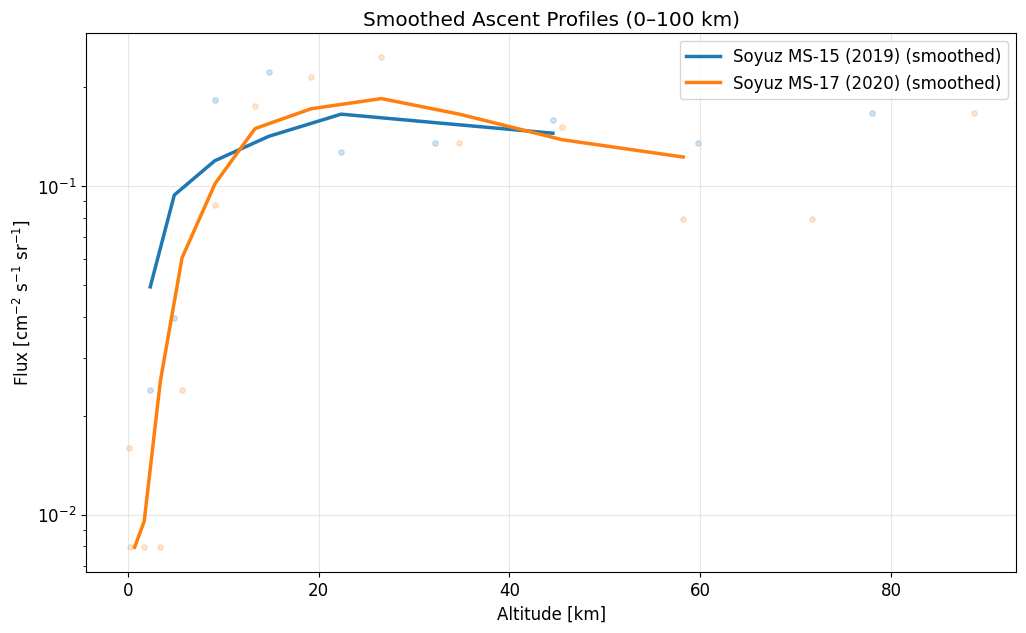

In [107]:
import matplotlib.pyplot as plt
import pandas as pd

if 'precise_shift_19' in globals() and 'poly_func' in globals():
    plt.figure(figsize=(12, 7))
    window_size = 5

    plot_data_ascent = [
        (rc19, events_2019, 'tab:blue',   "Soyuz MS-15 (2019)", precise_shift_19),
        (rc20, events_2020, 'tab:orange', "Soyuz MS-17 (2020)", precise_shift_20),
    ]

    for rc, events, color, label, time_shift in plot_data_ascent:
        launch = events['Launch']
        tmin_filter = launch - pd.Timedelta(seconds=time_shift)
        tmax_filter = launch + pd.Timedelta(seconds=157 - time_shift)

        z = rc.loc[(rc['corr_time'] >= tmin_filter) & (rc['corr_time'] <= tmax_filter)].copy()
        z['t_sec_shifted'] = (z['corr_time'] + pd.Timedelta(seconds=time_shift) - launch).dt.total_seconds()
        z['altitude_km'] = poly_func(z['t_sec_shifted'])

        # Smoothing
        z['flux_smoothed'] = z['flux'].rolling(window=window_size, center=True).mean()
        plt.scatter(z['altitude_km'], z['flux'], s=15, alpha=0.2, color=color)
        plt.plot(z['altitude_km'], z['flux_smoothed'], lw=2.5, color=color, label=f"{label} (smoothed)")

    plt.yscale('log')
    plt.xlabel('Altitude [km]')
    plt.ylabel(r'Flux [cm$^{-2}$ s$^{-1}$ sr$^{-1}$]')
    plt.title('Smoothed Ascent Profiles (0–100 km)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
else:
    print("Dependencies missing: Ensure shifts and altitude fits are calculated.")

### Log-Normal Fit: Regener-Pfotzer Maximum

A log-normal function is often used to model the vertical profile of ionizing radiation in the atmosphere, describing the increase and subsequent decrease (Regener maximum) of the particle flux:

$$f(h) = A \cdot \exp\left( -\frac{(\ln(h) - \mu)^2}{2\sigma^2} \right)$$

where $h$ is altitude, $A$ is amplitude, $\mu$ relates to the peak position, and $\sigma$ to the peak width.

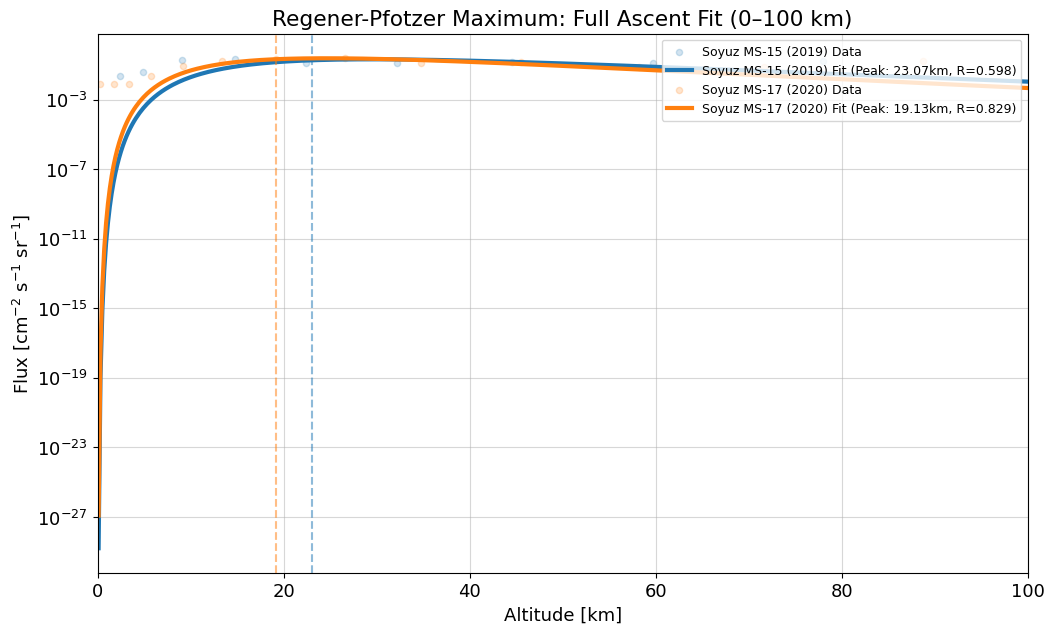


--- Comparison Results (Full Ascent Range) ---
Soyuz MS-15 (2019): Peak 23.07 km (Pearson R: 0.598)
Soyuz MS-17 (2020): Peak 19.13 km (Pearson R: 0.829)


In [148]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
from scipy.optimize import curve_fit

if 'precise_shift_19' in globals() and 'poly_func' in globals():
    plt.figure(figsize=(12, 7))
    results_corr = []

    def log_normal(h, A, mu, sigma):
        # Standard log-normal pdf scaling for flux
        # Added small epsilon to h to avoid log(0)
        return A * np.exp(-((np.log(np.maximum(h, 0.1)) - mu)**2) / (2 * sigma**2))

    plot_data_ascent = [
        (rc19, events_2019, 'tab:blue',   "Soyuz MS-15 (2019)", precise_shift_19),
        (rc20, events_2020, 'tab:orange', "Soyuz MS-17 (2020)", precise_shift_20),
    ]

    for rc, events, color, label, time_shift in plot_data_ascent:
        launch = events['Launch']
        tmin_f = launch - pd.Timedelta(seconds=time_shift)
        tmax_f = launch + pd.Timedelta(seconds=157 - time_shift) # Up to ~100km

        z = rc.loc[(rc['corr_time'] >= tmin_f) & (rc['corr_time'] <= tmax_f)].copy()
        z['t_sec_shifted'] = (z['corr_time'] + pd.Timedelta(seconds=time_shift) - launch).dt.total_seconds()
        z['altitude_km'] = poly_func(z['t_sec_shifted'])

        z_corr = z.dropna(subset=['altitude_km', 'flux']).copy()

        # MODIFIED: Use the full range (0-100km) as in the previous cell
        z_corr = z_corr[(z_corr['altitude_km'] >= 0.1) & (z_corr['altitude_km'] <= 100.0)]

        # Smoothing to stabilize fit
        z_corr['flux_smooth'] = z_corr['flux'].rolling(window=3, center=True).mean().fillna(z_corr['flux'])

        # Initial guesses: A=max flux, mu=ln(expected peak ~22km), sigma=width
        p0 = [z_corr['flux_smooth'].max(), np.log(22), 0.2]
        bounds = ([0, np.log(10), 0.01], [np.inf, np.log(40), 0.5])

        try:
            popt, _ = curve_fit(log_normal, z_corr['altitude_km'], z_corr['flux_smooth'], p0=p0, bounds=bounds)
            A_fit, mu_fit, sigma_fit = popt

            # Peak of log-normal mode: exp(mu - sigma^2)
            h_peak = np.exp(mu_fit - sigma_fit**2)

            # Calculate Pearson R between smoothed data and the fit
            r_coeff, _ = pearsonr(z_corr['flux_smooth'], log_normal(z_corr['altitude_km'], *popt))
            results_corr.append({'Mission': label, 'Peak Alt [km]': h_peak, 'R': r_coeff})

            plt.scatter(z_corr['altitude_km'], z_corr['flux'], s=20, alpha=0.2, color=color, label=f"{label} Data")
            h_fine = np.linspace(0.1, 100, 500)
            plt.plot(h_fine, log_normal(h_fine, *popt), lw=3, color=color,
                     label=f"{label} Fit (Peak: {h_peak:.2f}km, R={r_coeff:.3f})")
            plt.axvline(h_peak, color=color, ls='--', alpha=0.5)

        except Exception as e:
            print(f"Fit failed for {label}: {e}")

    plt.yscale('log')
    plt.xlim(0, 100)
    plt.xlabel('Altitude [km]')
    plt.ylabel(r'Flux [cm$^{-2}$ s$^{-1}$ sr$^{-1}$]')
    plt.title('Regener-Pfotzer Maximum: Full Ascent Fit (0–100 km)')
    plt.legend(fontsize=9, loc='upper right')
    plt.grid(True, which='both', alpha=0.5)
    plt.show()

    print("\n--- Comparison Results (Full Ascent Range) ---")
    for res in results_corr:
        print(f"{res['Mission']}: Peak {res['Peak Alt [km]']:.2f} km (Pearson R: {res['R']:.3f})")
else:
    print("Dependency Missing: Ensure precise_shift and poly_func are defined.")

### 13. Total Dose Calculation (Launch → Docking)

We integrate the `ddsi` values (dose rate in µGy/h) over time from launch to docking for both missions.

In [109]:
dose_results = []

for mission_label, rc_df, events in [
    ("Soyuz MS-15 (2019)", rc19, events_2019),
    ("Soyuz MS-17 (2020)", rc20, events_2020)
]:
    t_start = events['Launch']
    t_end = events['Docking']

    # Filtrování dat pro fázi letu k ISS
    mask = (rc_df['corr_time'] >= t_start) & (rc_df['corr_time'] <= t_end)
    flight_data = rc_df.loc[mask].copy()

    # Výpočet doby trvání (v hodinách)
    duration_hours = (t_end - t_start).total_seconds() / 3600.0

    if not flight_data.empty:
        # Seřazení podle času pro správnou integraci
        flight_data = flight_data.sort_values('corr_time')

        # Čas v sekundách od startu
        t_seconds = (flight_data['corr_time'] - t_start).dt.total_seconds().values
        y_ddsi = flight_data['ddsi'].values

        # Integrace pomocí moderní funkce np.trapezoid
        # Výsledek integrace je [uGy/h * s]
        integrated_seconds = np.trapezoid(y_ddsi, x=t_seconds)

        # Převod na [uGy] (vydělením 3600 s/h)
        total_dose_ugy = integrated_seconds / 3600.0

        dose_results.append({
            'Mission': mission_label,
            'Duration [h]': round(duration_hours, 2),
            'Total Dose [µGy]': round(total_dose_ugy, 2)
        })

df_dose = pd.DataFrame(dose_results)
display(df_dose)

,Mission,Duration [h],Total Dose [µGy]
0,Soyuz MS-15 (2019),5.75,188.16
1,Soyuz MS-17 (2020),3.06,249.28


### 14. Visualization: Flight Phase (Launch to Docking)
This plot compares the radiation environment for both missions during the active flight phase to the ISS.

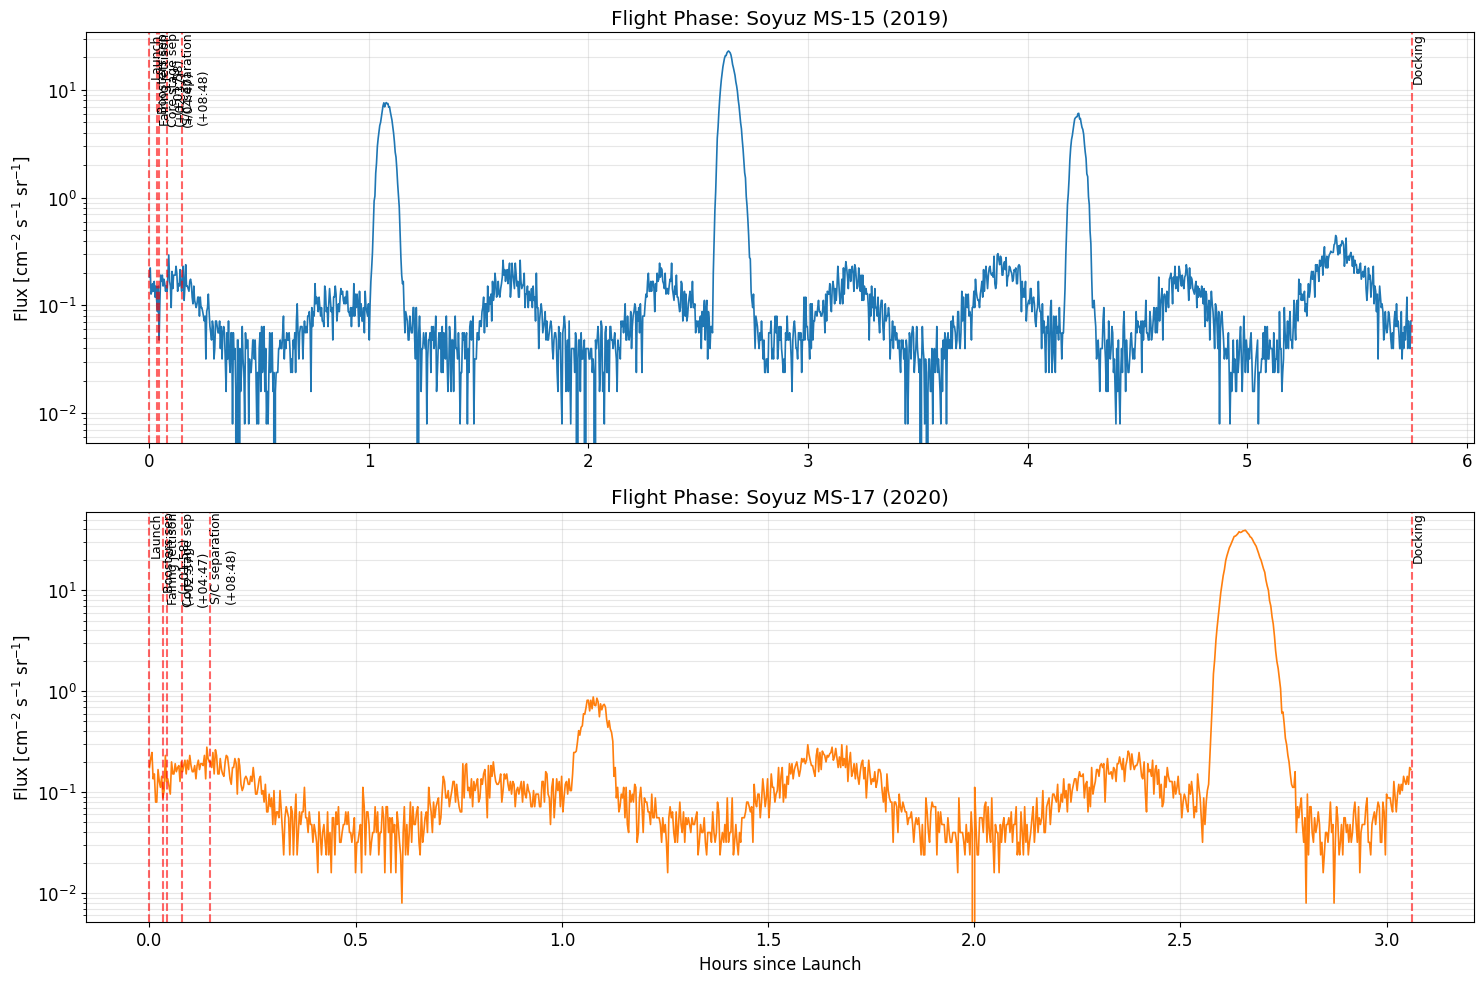

In [118]:
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=False)

for i, (mission_label, rc_df, events, color) in enumerate([
    ("Soyuz MS-15 (2019)", rc19, events_2019, 'tab:blue'),
    ("Soyuz MS-17 (2020)", rc20, events_2020, 'tab:orange')
]):
    ax = axes[i]
    t_start = events['Launch']
    t_end = events['Docking']

    # Filter data for the flight phase
    mask = (rc_df['corr_time'] >= t_start) & (rc_df['corr_time'] <= t_end)
    flight_data = rc_df.loc[mask].copy()
    flight_data['t_hours'] = (flight_data['corr_time'] - t_start).dt.total_seconds() / 3600.0

    ax.plot(flight_data['t_hours'], flight_data['flux'], color=color, lw=1.2, label=mission_label)
    ax.set_yscale('log')
    ax.set_ylabel(r'Flux [cm$^{-2}$ s$^{-1}$ sr$^{-1}$]')
    ax.set_title(f'Flight Phase: {mission_label}')
    ax.grid(True, which='both', alpha=0.3)

    # Draw specific events within this window
    for name, t in events.items():
        t_rel = (t - t_start).total_seconds() / 3600.0
        if 0 <= t_rel <= (t_end - t_start).total_seconds() / 3600.0:
            ax.axvline(t_rel, color='red', linestyle='--', alpha=0.6)
            ax.text(t_rel, ax.get_ylim()[1], name, rotation=90, va='top', fontsize=9)

axes[1].set_xlabel('Hours since Launch')
plt.tight_layout()
plt.savefig("flight_phase_comparison.png", dpi=300)
plt.show()

### 15. Comparison of Total Dose and Average Dose Rate from the First Week

Calculation for the entire loaded time range (~7 days for each mission).

In [110]:
full_week_comparison = []

for label, rc in [
    ("Soyuz MS-15 (2019)", rc19),
    ("Soyuz MS-17 (2020)", rc20)
]:
    df_clean = rc.dropna(subset=['corr_time', 'ddsi']).sort_values('corr_time')
    t_start = df_clean['corr_time'].min()
    t_end = df_clean['corr_time'].max()

    duration_h = (t_end - t_start).total_seconds() / 3600.0
    duration_d = duration_h / 24.0

    t_sec = (df_clean['corr_time'] - t_start).dt.total_seconds().values
    y_val = df_clean['ddsi'].values

    total_dose_ugy = np.trapezoid(y_val, x=t_sec) / 3600.0
    daily_rate = total_dose_ugy / duration_d

    full_week_comparison.append({
        'Mission': label,
        'Period [days]': round(duration_d, 2),
        'Total Dose [µGy]': round(total_dose_ugy, 2),
        'Avg Daily Dose Rate [µGy/day]': round(daily_rate, 2)
    })

df_full_week = pd.DataFrame(full_week_comparison)
display(df_full_week)

ratio_full = df_full_week.iloc[1]['Avg Daily Dose Rate [µGy/day]'] / df_full_week.iloc[0]['Avg Daily Dose Rate [µGy/day]']
print(f"\nOver the entire first week, the MS-17 mission shows {((ratio_full-1)*100):.1f}% higher average radiation than MS-15 (ratio {ratio_full:.2f}x).")

,Mission,Period [days],Total Dose [µGy],Avg Daily Dose Rate [µGy/day]
0,Soyuz MS-15 (2019),7.14,3342.03,468.17
1,Soyuz MS-17 (2020),9.85,6763.79,686.80



Over the entire first week, the MS-17 mission shows 46.7% higher average radiation than MS-15 (ratio 1.47x).


## 16. Analysis of the Final Segment (Last ~7 Days)

To analyze the end of the mission segments, we will reload the data from the end of the files. Since the CSV files are large, we calculate the number of lines to skip to read only the last `N_ROWS`.

In [111]:
import pandas as pd
import os
import gdown

# Ensure files are present
FILE_ID_2019 = '1iNoPx-lP6MwSoZj_PMbKcX4QorqoFq0g'
FILE_ID_2020 = '1AA8k2UhesWp0x2KbCycyiJnCheM1HXJ5'

if not os.path.exists('iss2019.csv'):
    gdown.download(f'https://drive.google.com/uc?id={FILE_ID_2019}', 'iss2019.csv', quiet=False)
if not os.path.exists('iss2020.csv'):
    gdown.download(f'https://drive.google.com/uc?id={FILE_ID_2020}', 'iss2020.csv', quiet=False)

def get_total_lines(filename):
    with open(filename, 'rb') as f:
        return sum(1 for _ in f)

N_ROWS_LAST = 80_000
USE_COLS = ['corr_time', 'flux', 'ddsi']

# 2019
total_19 = get_total_lines('iss2019.csv')
rc19_last = pd.read_csv('iss2019.csv', usecols=USE_COLS, skiprows=range(1, max(1, total_19 - N_ROWS_LAST)))
rc19_last['corr_time'] = pd.to_datetime(rc19_last['corr_time'], utc=True, format='mixed')

# 2020
total_20 = get_total_lines('iss2020.csv')
rc20_last = pd.read_csv('iss2020.csv', usecols=USE_COLS, skiprows=range(1, max(1, total_20 - N_ROWS_LAST)))
rc20_last['corr_time'] = pd.to_datetime(rc20_last['corr_time'], utc=True, format='mixed')

print(f'2019 Last segment range: {rc19_last["corr_time"].min()} to {rc19_last["corr_time"].max()}')
print(f'2020 Last segment range: {rc20_last["corr_time"].min()} to {rc20_last["corr_time"].max()}')

2019 Last segment range: 2020-01-23 15:41:46.244999999+00:00 to 2020-02-08 00:10:42.944999998+00:00
2020 Last segment range: 2021-03-17 07:51:36.258520+00:00 to 2021-03-27 07:08:20.486259999+00:00


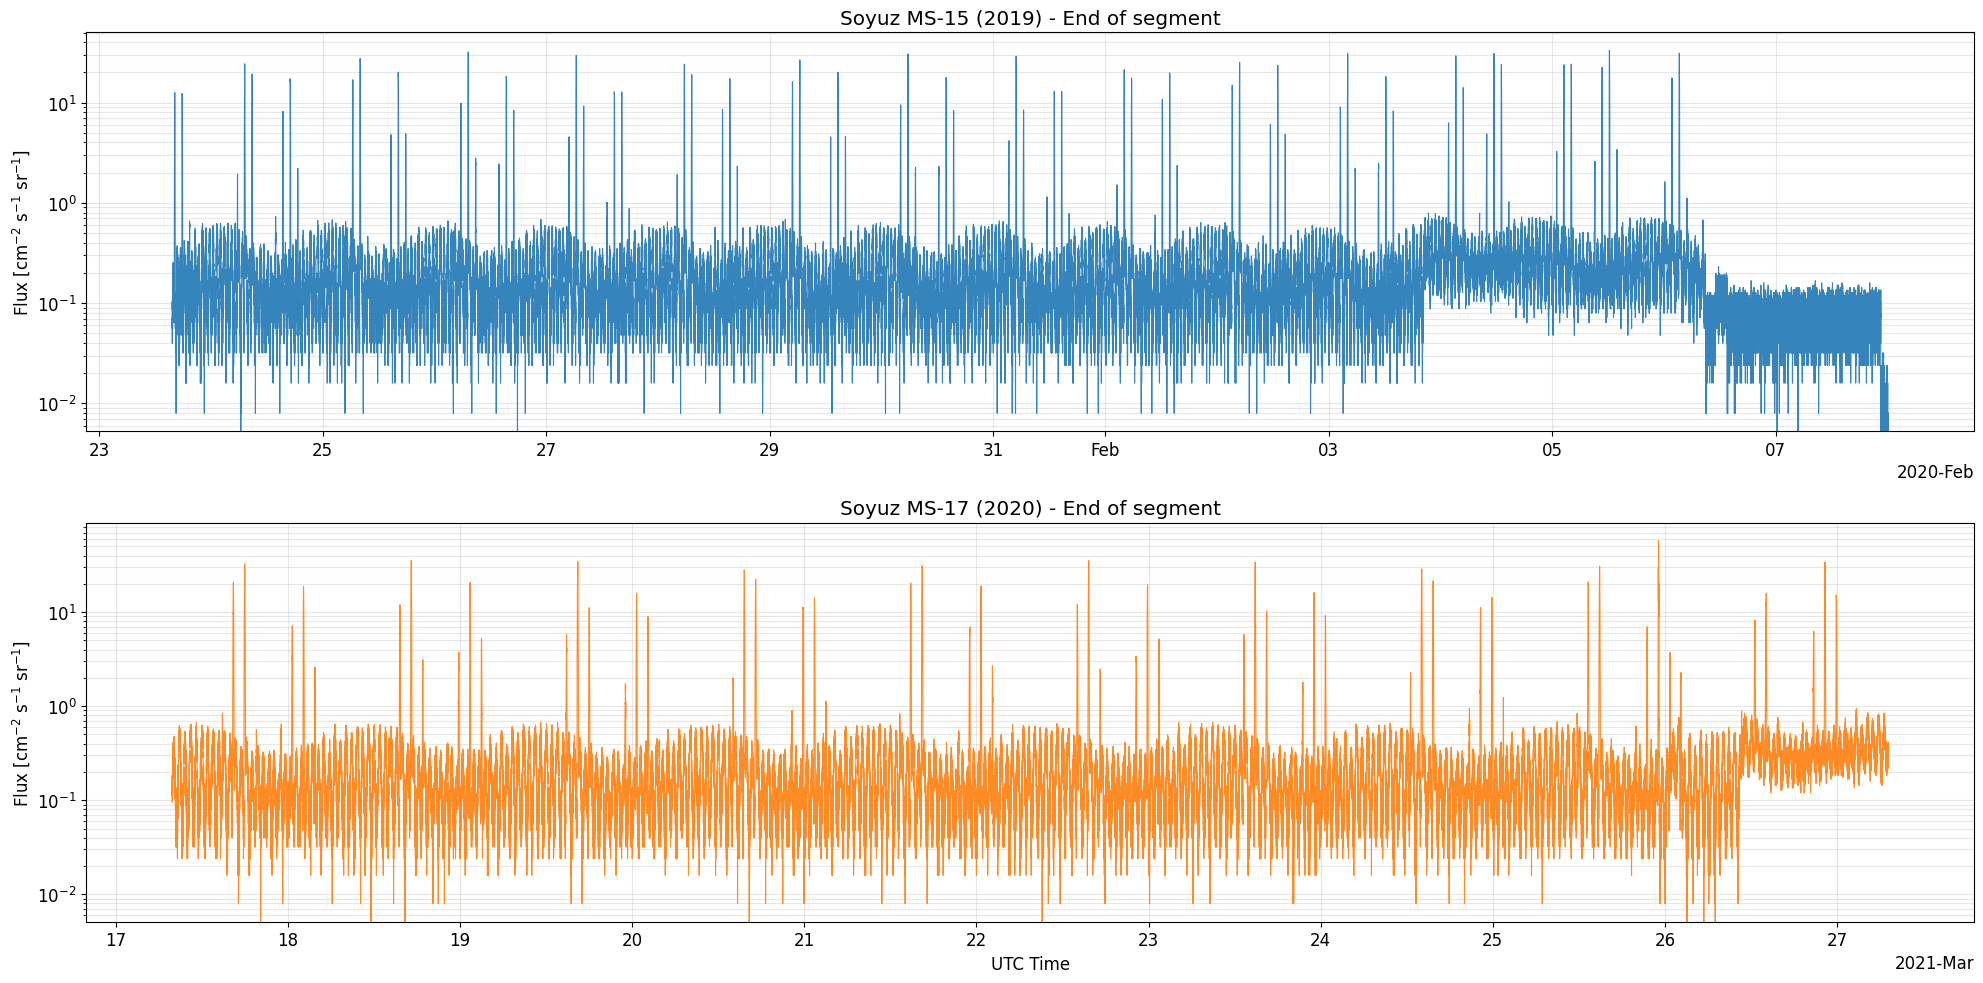

In [112]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 1, figsize=(20, 10), sharex=False)

for i, (ax, rc, color, label) in enumerate([
    (axes[0], rc19_last, 'tab:blue', 'Soyuz MS-15 (2019) - End of segment'),
    (axes[1], rc20_last, 'tab:orange', 'Soyuz MS-17 (2020) - End of segment')
]):
    ax.plot(rc['corr_time'], rc['flux'], color=color, lw=0.8, alpha=0.9, label='Flux')
    ax.set_yscale('log')
    ax.set_ylabel(r'Flux [cm$^{-2}$ s$^{-1}$ sr$^{-1}$]')
    ax.set_title(label)
    ax.grid(which='both', alpha=0.3)
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))

axes[1].set_xlabel('UTC Time')
plt.tight_layout()
plt.savefig("end_mission_segment_comparison.png", dpi=300)
plt.show()

### 17. Detail of MS-15 (2019) End-of-Mission: Undocking and Landing

This plot focuses on the final day of the MS-15 mission data, highlighting the return of the crew (landing of MS-13).

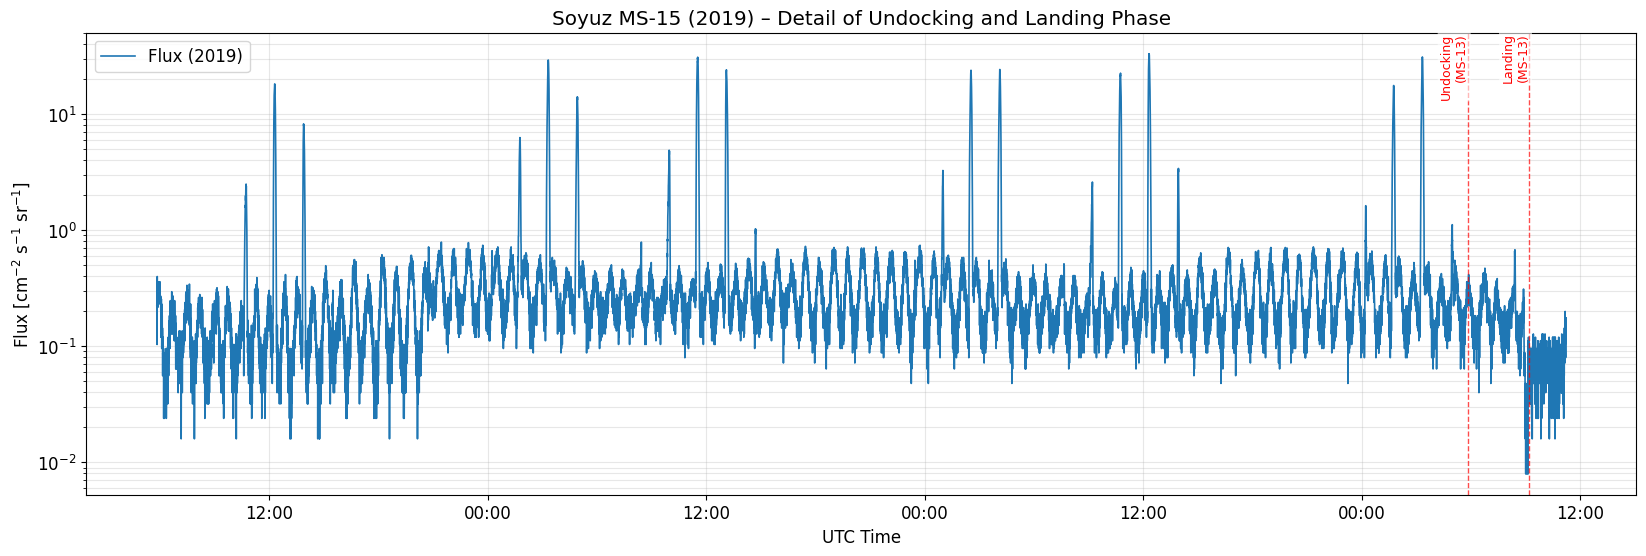

In [113]:
plt.figure(figsize=(20, 6))

# Filter for 2019 end segment
tmin_end = events_2019['Undocking\n(MS-13)'] - pd.Timedelta(hours=72)
tmax_end = events_2019['Landing\n(MS-13)'] + pd.Timedelta(hours=2)

z_end = rc19_last.loc[(rc19_last['corr_time'] >= tmin_end) & (rc19_last['corr_time'] <= tmax_end)]

plt.plot(z_end['corr_time'], z_end['flux'], color='tab:blue', lw=1.2, label='Flux (2019)')
plt.yscale('log')

# Mark events
draw_events(plt.gca(), events_2019, tmin_end, tmax_end, color='red')

plt.title('Soyuz MS-15 (2019) – Detail of Undocking and Landing Phase')
plt.ylabel(r'Flux [cm$^{-2}$ s$^{-1}$ sr$^{-1}$]')
plt.xlabel('UTC Time')
plt.grid(True, which='both', alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.legend()
plt.savefig("ms15_undocking_landing_raw.png", dpi=300)
plt.show()

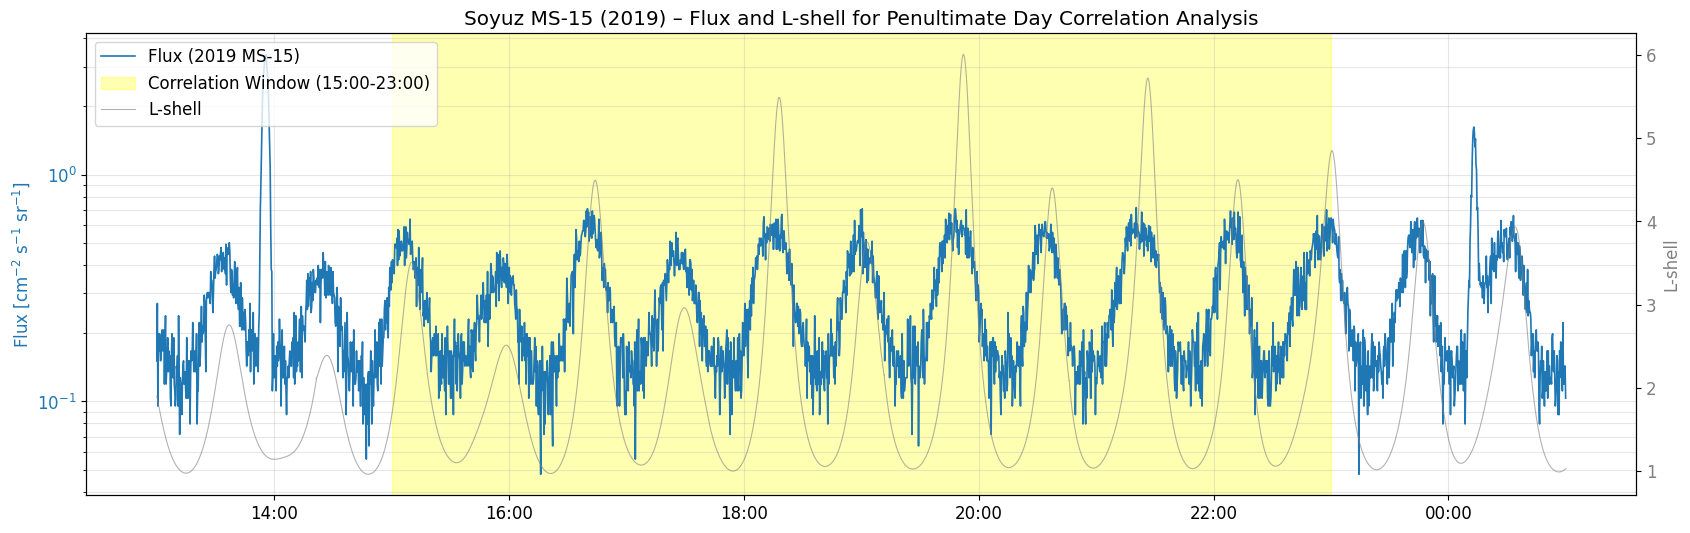

Correlation window set from 2020-02-05 15:00:00+00:00 to 2020-02-05 23:00:00+00:00


In [114]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Define the window: Penultimate day of 2019 data (Feb 5, 2020)
tmin_corr_window = pd.Timestamp("2020-02-05 15:00:00", tz="UTC")
tmax_corr_window = pd.Timestamp("2020-02-05 23:00:00", tz="UTC")

# Filter flux data for visualization
z_view = rc19_last.loc[(rc19_last['corr_time'] >= tmin_corr_window - pd.Timedelta(hours=2)) &
                       (rc19_last['corr_time'] <= tmax_corr_window + pd.Timedelta(hours=2))]

# Filter orbit data for visualization
orbit_view = orbit19_end.loc[(orbit19_end['UTC'] >= tmin_corr_window - pd.Timedelta(hours=2)) &
                             (orbit19_end['UTC'] <= tmax_corr_window + pd.Timedelta(hours=2))]

plt.figure(figsize=(20, 6))
ax = plt.gca()

# Plot Flux on primary y-axis
ax.plot(z_view['corr_time'], z_view['flux'], color='tab:blue', lw=1.2, label='Flux (2019 MS-15)')
ax.set_yscale('log')
ax.set_ylabel(r'Flux [cm$^{-2}$ s$^{-1}$ sr$^{-1}$]', color='tab:blue')
ax.tick_params(axis='y', labelcolor='tab:blue')

# Create twin axis for L-shell on secondary y-axis
ax2 = ax.twinx()
ax2.plot(orbit_view['UTC'], orbit_view['L'], color='gray', lw=0.8, alpha=0.6, label='L-shell')
ax2.set_ylabel('L-shell', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

# Highlight the correlation window
ax.axvspan(tmin_corr_window, tmax_corr_window, color='yellow', alpha=0.3, label='Correlation Window (15:00-23:00)')

plt.title('Soyuz MS-15 (2019) – Flux and L-shell for Penultimate Day Correlation Analysis')
plt.xlabel('UTC Time (2020-02-05)')
ax.grid(True, which='both', alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# Combine legends from both axes
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc='upper left')

plt.savefig("correlation_window_overview.png", dpi=300)
plt.show()

print(f"Correlation window set from {tmin_corr_window} to {tmax_corr_window}")

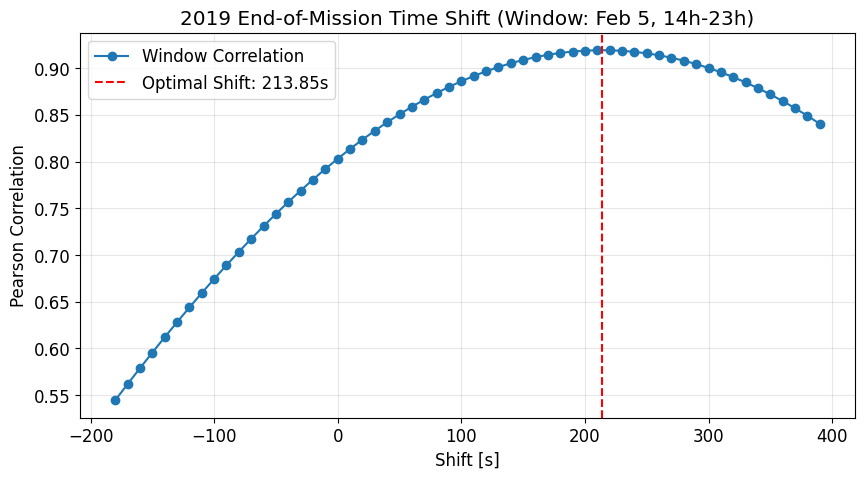

Refined Optimal Shift for 2019 End-Phase: 213.85 seconds
Maximum Correlation in window: 0.9193


In [115]:
# 1. Filter data for the specific 2019 window (Feb 5, 2020, 14:00-23:00 UTC)
tmin_win = pd.Timestamp("2020-02-05 15:00:00", tz="UTC")
tmax_win = pd.Timestamp("2020-02-05 23:00:00", tz="UTC")

rc19_win = rc19_last.loc[(rc19_last['corr_time'] >= tmin_win) & (rc19_last['corr_time'] <= tmax_win)].copy()
orbit19_win = orbit19_end.loc[(orbit19_end['UTC'] >= tmin_win - pd.Timedelta(minutes=10)) &
                              (orbit19_end['UTC'] <= tmax_win + pd.Timedelta(minutes=10))].copy()

# 2. Calculate correlations for a range of shifts
shifts_fine = np.arange(-180, 400, 10)
corrs19_win = [calculate_shifted_correlation(rc19_win, orbit19_win, s) for s in shifts_fine]

# 3. Find precise peak via parabolic fit
ps19_win, pc19_win, err19_win = find_precise_peak(shifts_fine, corrs19_win)

# 4. Visualization of the correlation curve
plt.figure(figsize=(10, 5))
plt.plot(shifts_fine, corrs19_win, 'o-', color='tab:blue', label='Window Correlation')
plt.axvline(ps19_win, color='red', linestyle='--', label=f'Optimal Shift: {ps19_win:.2f}s')
plt.title('2019 End-of-Mission Time Shift (Window: Feb 5, 14h-23h)')
plt.xlabel('Shift [s]')
plt.ylabel('Pearson Correlation')
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig("end_mission_drift_analysis.png", dpi=300)
plt.show()

print(f"Refined Optimal Shift for 2019 End-Phase: {ps19_win:.2f} seconds")
print(f"Maximum Correlation in window: {pc19_win:.4f}")

### 19. Final 2019 Mission Segment with Corrected Time-Shift
Using the refined shift of **213.85 seconds**, we can now visualize the landing phase of Soyuz MS-15 with improved temporal alignment.

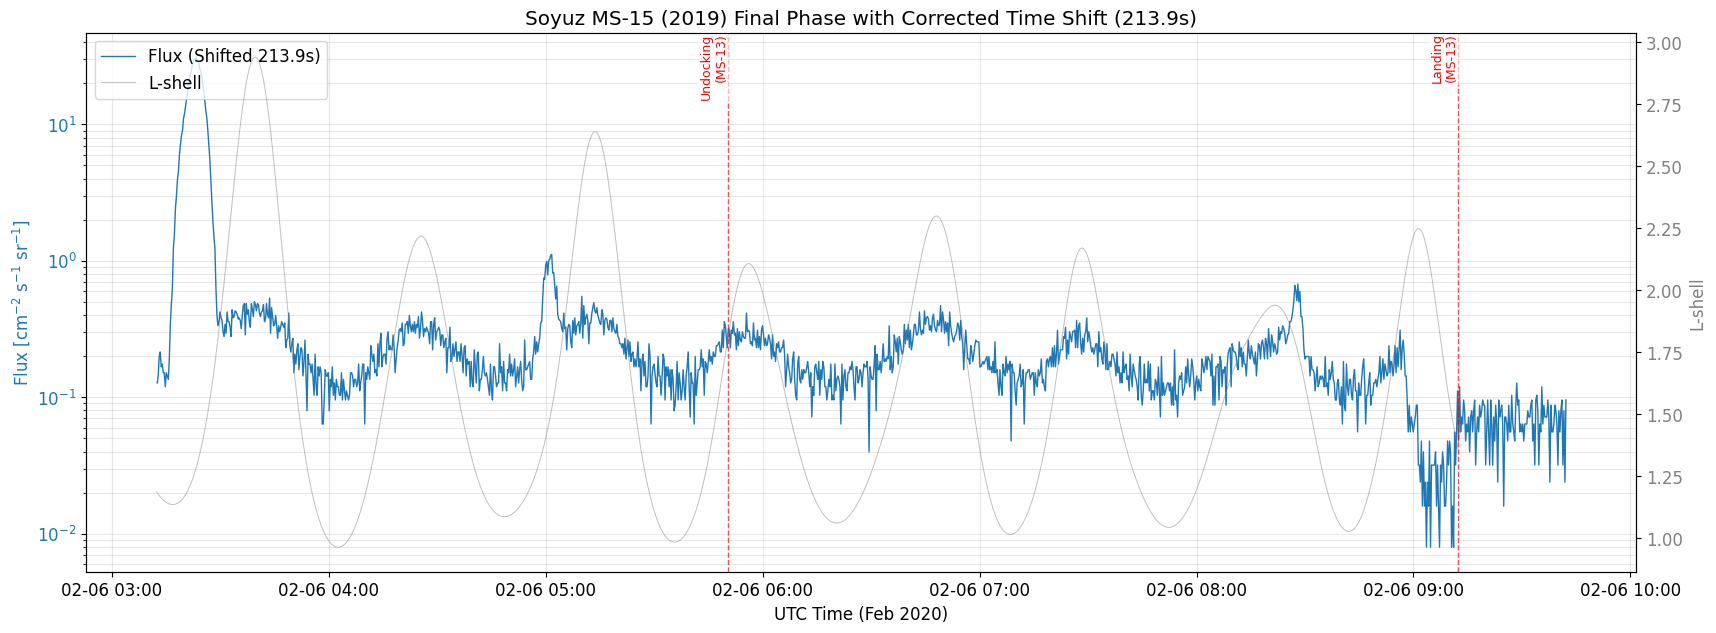

In [116]:
plt.figure(figsize=(20, 7))
ax1 = plt.gca()

# Apply the NEWLY discovered shift for the end-phase
shift_end_2019 = ps19_win # ~213.85s

# Filter 2019 end segment for the last 48 hours including undocking/landing
tmax_landing = events_2019['Landing\n(MS-13)']
tmin_view = tmax_landing - pd.Timedelta(hours=6)

# Shift the data for visualization
rc19_shifted = rc19_last.copy()
rc19_shifted['time_corr'] = rc19_shifted['corr_time'] + pd.Timedelta(seconds=shift_end_2019)

z_plot = rc19_shifted.loc[(rc19_shifted['time_corr'] >= tmin_view) & (rc19_shifted['time_corr'] <= tmax_landing + pd.Timedelta(minutes=30))]
orb_plot = orbit19_end.loc[(orbit19_end['UTC'] >= tmin_view) & (orbit19_end['UTC'] <= tmax_landing + pd.Timedelta(minutes=30))]

# Plot Flux
ax1.plot(z_plot['time_corr'], z_plot['flux'], color='tab:blue', lw=1, label=f'Flux (Shifted {shift_end_2019:.1f}s)')
ax1.set_yscale('log')
ax1.set_ylabel(r'Flux [cm$^{-2}$ s$^{-1}$ sr$^{-1}$]', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Plot L-shell
ax2 = ax1.twinx()
ax2.plot(orb_plot['UTC'], orb_plot['L'], color='gray', lw=0.7, alpha=0.5, label='L-shell')
ax2.set_ylabel('L-shell', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

# Mark Events
draw_events(ax1, events_2019, tmin_view, tmax_landing + pd.Timedelta(minutes=30), color='red')

plt.title(f'Soyuz MS-15 (2019) Final Phase with Corrected Time Shift ({shift_end_2019:.1f}s)')
ax1.set_xlabel('UTC Time (Feb 2020)')
ax1.grid(True, which='both', alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))

# Combined Legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc='upper left')

plt.savefig("ms15_landing_final_corrected.png", dpi=300)
plt.show()